# Fine-scale H&E ↔ MALDI-MSI alignment (clean rebuild)

Rebuilt from scratch against `Fine_scale_HE_MSI_alignment_new_methods.pdf`.

**Scope:** locally-normalised Wendland projection of an H&E sinusoid field → peri-fiducial
metafeature learning with split-set radius selection → smooth TPS residual deformation →
nucleus-associated MSI metafeature with spatially held-out localisation validation.
Tear detection / tear-aware refinement (Supp. 2.7–2.8) is **out of scope** here, so the
trusted set is the full spot set and the smooth TPS $T_1$ is the final transform.

## Chunk 1 — imports, fixed hyperparameters & input paths

Three cells: library imports; every methods-paper constant (none tuned); every input file
path any downstream chunk reads, gathered in one place with an existence check.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy import ndimage as ndi
from scipy import optimize
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from scipy.interpolate import RegularGridInterpolator

import json

import skimage
from skimage import io as skio
from skimage.color import rgb2hsv
from skimage.draw import polygon as draw_polygon
from skimage.measure import label as sk_label
from skimage.segmentation import clear_border
from skimage.morphology import binary_closing, binary_opening, skeletonize, disk, remove_small_objects

from sklearn.linear_model import Ridge
from sklearn.neighbors import NearestNeighbors

from pyimzml.ImzMLParser import ImzMLParser, getionimage

# ---------------------------------------------------------------------------
# Fixed hyperparameters (methods paper — none of these are tuned)
# ---------------------------------------------------------------------------

# Sec. 2.3 / 2.9 : ridge penalty for every metafeature regression
LAMBDA_RIDGE = 0.05

# Sec. 2.4 : peri-fiducial neighbourhood construction
N_BIPARTITIONS = 10          # B  — repeated fiducial bipartitions
N_INTERMEDIATE_RADII = 8     # candidate radii between r_min and r_max
MIN_SPOTS_FEATURE_MULT = 3   # n_A(r) >= max(3p, 0.05|N|)
MIN_SPOTS_SLIDE_FRAC = 0.05
MIN_TARGET_VAR_FRAC = 0.5    # v_A(r) >= 0.5 * v_all
BIPARTITION_SEED = 0         # RNG seed for the bipartition sampling (reproducibility)

# Sec. 2.5 : radius selection tolerance on the validation correlation
RADIUS_C_TOL = 0.01          # keep largest r with C(r) >= C_max - 0.01

# Sec. 2.6 : smooth thin-plate spline
TPS_MAX_CENTRES = 150        # K_max
TPS_FID_RESIDUAL_PX = 1.0    # D_fid(k) <= 1 MSI pixel selects lambda_TPS = 2**k

# Sec. 2.9 : nucleus-associated metafeature
H_MIN = 0.9                  # hepatocyte-fraction cutoff for the eligible set I
SIGMA_BG_MULT = 4.0          # sigma_bg = 4 * d_MSI  (local linear background scale)

# Sec. 2.10 : spatial validation of nucleus localisation
N_CHECKER_TILES = 5          # 5 x 5 checkerboard
SIGMA_PEAK_MULT = 0.5        # sigma_peak = 0.5 * d_MSI  (tight pre-detection smoothing)
MATCH_DIST_MULT = 1.0        # d_match = 1 * d_MSI  (max one-to-one matching distance)
SHIFT_RANGE_MULT = 2.0       # shift-response grid spans [-2 d_MSI, 2 d_MSI]
SHIFT_STEP_MULT = 0.25       # ... at 0.25 d_MSI spacing

print("imports ok")

imports ok


In [2]:
# ---------------------------------------------------------------------------
# Input file paths — every file any downstream chunk reads, in one place.
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path("/home/kia/MALDI_Metabolomics")
SR_ROOT = PROJECT_ROOT / "metabol_data" / "space_ranger_segmented_outputs"

# --- MSI ---
IMZML_PATH = PROJECT_ROOT / "metabol_data" / "20251012_old_liver.imzML"

# --- H&E imagery (full-slide + the tissue-bounding-box crop) ---
HE_FULL_PATH = PROJECT_ROOT / "metabol_data" / "high_res_MSI" / "D2_10x_originalExport.tif"
HE_CROPPED_PATH = PROJECT_ROOT / "metabol_data" / "high_res_MSI" / "he_cropped.tif"
MALDI_MOVING_IMG_PATH = PROJECT_ROOT / "metabol_data" / "maldi_moving_img.png"

# --- initial transform T0 : MSI-pixel -> H&E-pixel coordinate map (fiducial-based) ---
# columns: msi_x, msi_y, he_x_affine, he_y_affine, he_x_tps, he_y_tps, displacement_px
T0_COORD_MAP_PATH = SR_ROOT / "cell_segmentations_out3_pixel_warp_affine_vs_tps.csv"

# --- fiducial landmark coordinates (columns: he_x, he_y, msi_x, msi_y) ---
FIDUCIALS_PATH = PROJECT_ROOT / "notebooks" / "fiducial_landmarks_nuclei.csv"

# --- H&E-derived segmentations, coordinates in full-slide H&E pixel space ---
GRAPHCLUST_PATH = SR_ROOT / "analysis" / "clustering" / "gene_expression_graphclust" / "clusters.csv"
CELL_SEG_GEOJSON_PATH = SR_ROOT / "graphclust_annotated_cell_segmentations.geojson"
NUCLEUS_SEG_GEOJSON_PATH = SR_ROOT / "graphclust_annotated_nucleus_segmentations.geojson"

# --- optional pre-computed sinusoid mask (alternative to the HSV recompute in Chunk 5) ---
SINUSOID_MASK_TIF = PROJECT_ROOT / "sinusoid_mask.tif"

# graph-expression clusters treated as hepatocytes -> M_hep (Sec. 2.9)
HEPATOCYTE_CLUSTER_IDS = [1, 2, 3, 4, 6, 7, 9]

# fail fast if anything is missing before the long peak-grouping step
for _p in [IMZML_PATH, HE_FULL_PATH, HE_CROPPED_PATH, MALDI_MOVING_IMG_PATH, T0_COORD_MAP_PATH,
           FIDUCIALS_PATH, GRAPHCLUST_PATH, CELL_SEG_GEOJSON_PATH, NUCLEUS_SEG_GEOJSON_PATH]:
    assert _p.exists(), f"missing input: {_p}"
print("all input paths present")

all input paths present


## Chunk 2 — MSI peak grouping → spot × feature matrix

`dbscan_1d_ish` is **reused verbatim** from `feature_based_alignment_nuclei.ipynb` (only the
redundant inner `import scipy.sparse as sp` was dropped — it is now a top-level import).

It performs a 1-D DBSCAN-style grouping of raw m/z values across all spectra: contiguous
runs where adjacent m/z gaps stay below `mz_tol` and that contain at least `min_count`
points become one feature (labelled by the cluster-median m/z); intensities are summed per
`(coordinate, feature)` pair into a sparse spot × feature matrix. This produces the
preprocessed matrix $X$ the paper assumes as input (Sec. 2.1), before feature QC.

In [3]:
def dbscan_1d_ish(imzml_path: str, mz_tol: float, min_intensity: float, min_count: int):
    """Group raw m/z values into features and build a sparse spot x feature matrix.

    A feature is a maximal run of sorted m/z values whose adjacent gaps are all
    below ``mz_tol`` and which contains at least ``min_count`` points. Each feature
    is labelled by the median m/z of its cluster; per-spot intensities are summed.

    Args:
        imzml_path (str): path to the .imzML file (its .ibd must sit alongside).
        mz_tol (float): max gap (Da) between adjacent m/z values within one feature.
        min_intensity (float): drop every peak with intensity <= this value first.
        min_count (int): minimum number of raw points for a run to become a feature;
            also the offset used for the running delta_mz calculation.

    Returns:
        spot_feature_matrix (scipy.sparse.csr_matrix): shape (n_spots, n_features),
            summed intensities, row i <-> coord_labels[i], col j <-> mz_labels[j].
        coord_labels (pd.Index): (x, y) MSI pixel coordinate tuples, one per row;
            sorted by pandas.groupby, NOT in the imzML's native spectrum order.
        mz_labels (pd.Index): cluster-median m/z value for each feature column.
    """
    parser = ImzMLParser(imzml_path)
    df = pd.DataFrame(
        (
            (*parser.getspectrum(idx), (x, y))
            for idx, (x, y, _) in enumerate(parser.coordinates)
        ),
        columns=["mzs", "intensities", "coordinates"],
    )
    # pull raw arrays out of the dataframe -- no copies yet
    mzs_arr = df["mzs"].to_numpy()
    intens_arr = df["intensities"].to_numpy()
    coords_arr = df["coordinates"].to_numpy()

    # single-pass concatenation -- much faster than explode
    all_mzs = np.concatenate(mzs_arr).astype(np.float32)
    all_intens = np.concatenate(intens_arr).astype(np.float32)
    lengths = np.fromiter((len(a) for a in mzs_arr), dtype=np.int32, count=len(mzs_arr))
    all_coords = np.repeat(coords_arr, lengths)

    # filter BEFORE building the dataframe -- avoids allocating rows you'll discard
    mask = all_intens > min_intensity
    all_mzs = all_mzs[mask]
    all_intens = all_intens[mask]
    all_coords = all_coords[mask]

    # sort on numpy arrays -- faster than df.sort_values + reset_index
    print(f"Sorting m/z values...{mask.sum()} values")
    order = np.argsort(all_mzs, kind="stable")

    print("building long_df")
    long_df = pd.DataFrame(
        {
            "mzs": all_mzs[order],
            "intensities": all_intens[order],
            "coordinates": all_coords[order],
        }
    )
    print(f"\nlong_df columns: {long_df.columns}\n")

    # deltas between m/z values min_count apart -- proxy for local density
    print("calculating deltas")
    delta_values = (
        -1 * long_df["mzs"].values[0 : (len(long_df) - min_count)]
        + long_df["mzs"].values[min_count : (len(long_df) + min_count)]
    )
    # 0-pad to match dataframe length
    long_df["delta_mz"] = np.concatenate([delta_values, [0] * min_count])
    del delta_values

    # boolean mask for dense regions (delta_mz < mz_tol)
    long_df["in_dense_region"] = (long_df["delta_mz"] < mz_tol).astype(int)

    # rising edges of in_dense_region -> new cluster numbers
    difference = np.diff(long_df["in_dense_region"].values)
    difference_plus = np.maximum(difference, 0)
    running_clusternr = np.cumsum(difference_plus)
    del difference, difference_plus

    delta = long_df["in_dense_region"].values
    # delta[:-1] and running_clusternr are both length n-1
    clusternr = delta[:-1] * running_clusternr
    del running_clusternr

    long_df["cluster_labels"] = np.concatenate([[delta[0]], clusternr])
    del clusternr, delta

    # drop noise (label 0) and clusters smaller than min_count
    long_df = long_df[long_df["cluster_labels"] != 0]
    long_df = long_df[
        long_df.groupby("cluster_labels")["mzs"].transform("size") >= min_count
    ]

    # sum intensities per (coordinate, cluster-median m/z)
    print("Grouping m/z values and summing intensities...")
    grouped = (
        long_df.assign(
            mz_label=long_df.groupby("cluster_labels")["mzs"].transform("median")
        )
        .groupby(["coordinates", "mz_label"])["intensities"]
        .sum()
    )

    print("Getting the coordinate and mz labels")
    coord_idx, coord_labels = pd.factorize(grouped.index.get_level_values("coordinates"))
    mz_idx, mz_labels = pd.factorize(grouped.index.get_level_values("mz_label"))

    print("Generating spot x feature matrix (sparse)...")
    spot_feature_matrix = sp.csr_matrix(
        (grouped.values, (coord_idx, mz_idx)),
        shape=(len(coord_labels), len(mz_labels)),
    )
    return spot_feature_matrix, coord_labels, mz_labels


In [4]:
# Same peak-grouping parameters as feature_based_alignment_nuclei.ipynb, so the
# feature set stays comparable to the previous results.
spot_feature_matrix, coord_labels, mz_labels = dbscan_1d_ish(
    str(IMZML_PATH), mz_tol=0.0042, min_intensity=5, min_count=25
)

print("spot x feature matrix :", spot_feature_matrix.shape)
print("n spots               :", len(coord_labels))
print("n features            :", len(mz_labels))
print("m/z range             :", f"{mz_labels.min():.4f} - {mz_labels.max():.4f}")
print("mean nnz per spot      :", spot_feature_matrix.nnz / spot_feature_matrix.shape[0])


/home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(


Sorting m/z values...39694844 values
building long_df

long_df columns: Index(['mzs', 'intensities', 'coordinates'], dtype='object')

calculating deltas
Grouping m/z values and summing intensities...
Getting the coordinate and mz labels
Generating spot x feature matrix (sparse)...
spot x feature matrix : (269511, 933)
n spots               : 269511
n features            : 933
m/z range             : 59.0124 - 616.3884
mean nnz per spot      : 139.38114585304496


## Chunk 3 — feature QC & frozen whole-slide standardisation

Sec. 2.1: *"Low-quality and low-variance features are removed, and the retained features are
centred and scaled to mean zero and variance one across the complete slide. This
standardisation is kept fixed throughout the alignment procedure."*

"Low-quality" is already handled upstream by `dbscan_1d_ish`'s peak-calling
(`min_intensity`/`min_count` in Chunk 2) — no separate filter is applied here. This chunk
implements only what the paper specifies literally, on the raw summed intensities (no log
transform, no clipping — both were in the old notebook but are not in the paper):

1. **low-variance drop** — features with zero empirical standard deviation across the slide;
2. centre / scale to whole-slide mean 0, variance 1 — computed once here, **never refit**.

Returns the frozen matrix `X` ($n\times p$), the per-feature `feat_mean` / `feat_scale` used,
and the boolean `feature_keep_mask` (to keep `mz_labels` column-aligned).

In [5]:
def standardize_features(spot_feature_matrix: sp.csr_matrix):
    """Drop zero-variance features and freeze a whole-slide standardisation (Sec. 2.1).

    Args:
        spot_feature_matrix (scipy.sparse.csr_matrix): shape (n_spots, n_features_raw),
            summed per-spot intensities from dbscan_1d_ish.

    Returns:
        X (np.ndarray): shape (n_spots, p), standardised features, mean 0 / var 1
            per column over the whole slide.
        feat_mean (np.ndarray): shape (p,), per-feature mean used to standardise --
            keep it, it is the fixed reference for any later re-projection.
        feat_scale (np.ndarray): shape (p,), per-feature standard deviation used
            to standardise.
        feature_keep_mask (np.ndarray): shape (n_features_raw,) bool, True for
            columns retained (std > 0) -- apply this to mz_labels to stay aligned.
    """
    X_raw = spot_feature_matrix.toarray().astype(np.float64)

    # low-variance drop: zero empirical std across the whole slide
    feature_keep_mask = X_raw.std(axis=0) > 0
    X_raw = X_raw[:, feature_keep_mask]

    # frozen whole-slide standardisation -- computed once, reused for every
    # downstream metafeature fit and never refit on a subset of spots
    feat_mean = X_raw.mean(axis=0)
    feat_scale = X_raw.std(axis=0)
    X = (X_raw - feat_mean) / feat_scale

    return X.astype(np.float32), feat_mean, feat_scale, feature_keep_mask


X, feat_mean, feat_scale, feature_keep_mask = standardize_features(spot_feature_matrix)
mz_labels = mz_labels[feature_keep_mask]  # keep column-aligned with X
p = X.shape[1]

print("X shape          :", X.shape)
print("features dropped :", (~feature_keep_mask).sum(), "/", len(feature_keep_mask))
print("per-feature mean/var of X (should be ~0 / ~1):", X.mean(), X.var())


X shape          : (269511, 933)
features dropped : 0 / 933
per-feature mean/var of X (should be ~0 / ~1): -3.281698e-10 1.0


## Chunk 4 — load spatial inputs (H&E, T₀, fiducials, MSI coordinates)

Loads the full-slide H&E image, the original MSI spot coordinates $\Omega_{\mathrm{MSI}}=\{u_i\}$,
the initial fiducial-based transform $T_0$ as a **coordinate array** (per the project note that
$T_0(U)$ is an array, not a callable), and the fiducial landmark coordinates $h_k$.

$T_0$ is joined to the spots **by native MSI pixel identity** `(msi_x, msi_y)`, not by row
order — `coord_labels` was re-sorted by `pandas.groupby` inside `dbscan_1d_ish`, so a
positional merge would silently mispair every spot (bug carried over as a fix from the old
notebook). Per your choice, $T_0$ uses the `he_x_tps` / `he_y_tps` columns.

The valid-tissue bounding box `bbox = (y_min, y_max, x_min, x_max)` is the integer extent of
the $T_0$-mapped spots; it defines the region where the H&E masks carry information (Sec. 2.1).

In [6]:
def load_spatial_inputs(he_full_path, t0_map_path, fiducials_path, coord_labels):
    """Load H&E imagery, the initial transform T0, and fiducial landmarks.

    Args:
        he_full_path (str | Path): full-slide H&E RGB TIFF.
        t0_map_path (str | Path): CSV with columns msi_x, msi_y, he_x_tps, he_y_tps
            (plus affine columns, unused), one row per MSI spot.
        fiducials_path (str | Path): CSV of fiducial landmarks with he_x, he_y columns.
        coord_labels (pd.Index): (x, y) MSI pixel coordinate tuples, row order of X.

    Returns:
        he_img (np.ndarray): (H, W, 3) uint8 full-slide H&E image.
        u (np.ndarray): (n, 2) float, original MSI spot coordinates u_i (MSI pixels),
            row-aligned to coord_labels / X.
        T0 (np.ndarray): (n, 2) float, u_i mapped into H&E pixel space by T0,
            row-aligned to coord_labels / X.
        he_fiducials (np.ndarray): (F, 2) float, fiducial coordinates h_k (H&E pixels).
        bbox (tuple[int, int, int, int]): (y_min, y_max, x_min, x_max) integer H&E
            bounding box of the T0-mapped spots.
    """
    he_img = skio.imread(str(he_full_path))
    u = np.array([(float(x), float(y)) for x, y in coord_labels], dtype=float)

    # join T0 by native MSI pixel identity, NOT row order (coord_labels is
    # groupby-sorted inside dbscan_1d_ish -> positional merge would mispair spots)
    tdf = pd.read_csv(t0_map_path)
    msi_to_he = {
        (float(r.msi_x), float(r.msi_y)): (float(r.he_x_tps), float(r.he_y_tps))
        for r in tdf.itertuples(index=False)
    }
    assert all((x, y) in msi_to_he for x, y in map(tuple, u)), "spot missing from T0 map"
    T0 = np.array([msi_to_he[(x, y)] for x, y in map(tuple, u)], dtype=float)

    he_fiducials = pd.read_csv(fiducials_path)[["he_x", "he_y"]].to_numpy(dtype=float)

    # valid-tissue bounding box from the T0-mapped spot extent (Sec. 2.1 crop region)
    x_min, x_max = int(np.floor(T0[:, 0].min())), int(np.ceil(T0[:, 0].max())) + 1
    y_min, y_max = int(np.floor(T0[:, 1].min())), int(np.ceil(T0[:, 1].max())) + 1
    return he_img, u, T0, he_fiducials, (y_min, y_max, x_min, x_max)


he_img, u, T0, he_fiducials, bbox = load_spatial_inputs(
    HE_FULL_PATH, T0_COORD_MAP_PATH, FIDUCIALS_PATH, coord_labels
)
y_min, y_max, x_min, x_max = bbox
print("he_img            :", he_img.shape, he_img.dtype)
print("MSI spots u       :", u.shape)
print("T0-mapped spots   :", T0.shape)
print("  x range         :", (round(T0[:, 0].min(), 1), round(T0[:, 0].max(), 1)))
print("  y range         :", (round(T0[:, 1].min(), 1), round(T0[:, 1].max(), 1)))
print("fiducials h_k     :", he_fiducials.shape)
print("bbox y,y,x,x      :", bbox)


he_img            : (12468, 15297, 3) uint8
MSI spots u       : (269511, 2)
T0-mapped spots   : (269511, 2)
  x range         : (np.float64(6975.4), np.float64(12154.0))
  y range         : (np.float64(3612.9), np.float64(8223.2))
fiducials h_k     : (16, 2)
bbox y,y,x,x      : (3612, 8225, 6975, 12155)


## Chunk 5 — H&E-derived masks (M, S_HE, M_hep, M_nuc)

All four masks live on the **full-slide H&E canvas** and are non-zero only inside `bbox`.

- **`M`** — valid-pixel mask (Sec. 2.1): 1 inside `bbox`, 0 in the padded border, so the
  Wendland projection in Chunk 7 can be locally re-normalised instead of treating padding as
  real background.
- **`S_HE`** — sinusoid anatomical mask, built per **Sec. 2.1**: convert the H&E crop to
  HSV, keep bright + weakly-saturated pixels (sinusoid lumen), then drop the exterior
  background (`clear_border`), specks (`remove_small_objects`), and large connected
  components (vessel lumina — the paper removes these with Cellpose/StarDist "or an
  equivalent procedure"; a max-area filter is the lightweight stand-in). A **separate cell**
  below can instead load the pre-computed `sinusoid_mask.tif`.
- **`M_hep`** — hepatocyte tissue mask: Space Ranger cell-segmentation polygons whose graph
  cluster is in `HEPATOCYTE_CLUSTER_IDS`, rasterised.
- **`M_nuc`** — nucleus mask: **all** nucleus-segmentation polygons (any cell type),
  rasterised, used directly with no extra filtering (Sec. 2.9).

Reuses the polygon-rasterisation and whiteness logic from the previous notebooks, ported off
`cv2.fillPoly` onto `skimage.draw.polygon`.

In [7]:
def build_valid_mask(he_shape: tuple, bbox: tuple) -> np.ndarray:
    """Valid-pixel mask M(z): 1 inside the tissue bounding box, 0 elsewhere (Sec. 2.1).

    Args:
        he_shape (tuple): full-slide H&E shape, (H, W) or (H, W, 3).
        bbox (tuple): (y_min, y_max, x_min, x_max) valid-tissue extent.

    Returns:
        M (np.ndarray): (H, W) float32, 1.0 inside bbox and 0.0 in the padded border.
    """
    y0, y1, x0, x1 = bbox
    M = np.zeros(he_shape[:2], dtype=np.float32)
    M[y0:y1, x0:x1] = 1.0
    return M


def sinusoid_mask_hsv(he_img: np.ndarray, bbox: tuple, v_min: float = 0.80,
                      s_max: float = 0.25, min_size: int = 40,
                      max_size: int = 2000) -> np.ndarray:
    """S_HE from an HSV brightness + saturation criterion (Sec. 2.1).

    Sinusoid lumen appears bright and weakly stained in H&E: high HSV value,
    low HSV saturation. After thresholding, exterior background is removed with
    clear_border, specks with a min-area filter, and large vessel lumina with a
    max-area filter (the paper's Cellpose/StarDist vessel removal, approximated).

    Args:
        he_img (np.ndarray): (H, W, 3) uint8 full-slide H&E image.
        bbox (tuple): (y_min, y_max, x_min, x_max) valid-tissue extent.
        v_min (float): minimum HSV value (brightness) for a candidate pixel, in [0, 1].
        s_max (float): maximum HSV saturation for a candidate pixel, in [0, 1].
        min_size (int): connected components smaller than this (px) are dropped as specks.
        max_size (int): connected components larger than this (px) are dropped as vessels.

    Returns:
        S_HE (np.ndarray): (H, W) float32 binary sinusoid mask on the full canvas.
    """
    y0, y1, x0, x1 = bbox
    hsv = rgb2hsv(he_img[y0:y1, x0:x1])
    cand = (hsv[..., 2] >= v_min) & (hsv[..., 1] <= s_max)
    cand = clear_border(cand)                        # exterior background
    cand = remove_small_objects(cand, min_size=min_size)

    lbl = sk_label(cand)
    comp_size = np.bincount(lbl.ravel())
    big = np.flatnonzero(comp_size > max_size)
    big = big[big != 0]                              # label 0 is background
    cand &= ~np.isin(lbl, big)                       # drop large vessel lumina

    S_HE = np.zeros(he_img.shape[:2], dtype=np.float32)
    S_HE[y0:y1, x0:x1] = cand.astype(np.float32)
    return S_HE


In [8]:
def rasterize_polygons(geojson_path, he_shape: tuple, bbox: tuple,
                       cluster_ids: set | None = None) -> np.ndarray:
    """Rasterise Space Ranger cell / nucleus polygons into a binary mask.

    Args:
        geojson_path (str | Path): Space Ranger *_segmentations.geojson; each feature
            carries geometry.coordinates[0] (an (x, y) polygon ring, full-slide H&E
            pixels) and, for cluster filtering, properties.classification.name of the
            form "cluster-<k>".
        he_shape (tuple): full-slide H&E shape, (H, W) or (H, W, 3).
        bbox (tuple): (y_min, y_max, x_min, x_max); polygons are drawn into this crop.
        cluster_ids (set[int] | None): keep only features whose cluster <k> is in this
            set; None keeps every feature.

    Returns:
        mask (np.ndarray): (H, W) float32 binary mask on the full canvas, non-zero
            only inside bbox.
    """
    y0, y1, x0, x1 = bbox
    with open(geojson_path) as fh:
        features = json.load(fh)["features"]

    crop = np.zeros((y1 - y0, x1 - x0), dtype=np.uint8)
    for ft in features:
        if cluster_ids is not None:
            k = int(ft["properties"]["classification"]["name"].split("-")[1])
            if k not in cluster_ids:
                continue
        ring = np.asarray(ft["geometry"]["coordinates"][0], dtype=float)
        # skimage.draw.polygon takes (row, col) = (y, x); clip to the crop shape
        rr, cc = draw_polygon(ring[:, 1] - y0, ring[:, 0] - x0, shape=crop.shape)
        crop[rr, cc] = 1

    mask = np.zeros(he_shape[:2], dtype=np.float32)
    mask[y0:y1, x0:x1] = crop
    return mask


In [9]:
M = build_valid_mask(he_img.shape, bbox)
#S_HE = sinusoid_mask_hsv(he_img, bbox)
M_hep = rasterize_polygons(CELL_SEG_GEOJSON_PATH, he_img.shape, bbox, set(HEPATOCYTE_CLUSTER_IDS))
M_nuc = rasterize_polygons(NUCLEUS_SEG_GEOJSON_PATH, he_img.shape, bbox, None)

for name, m in [("M", M), ("M_hep", M_hep), ("M_nuc", M_nuc)]:
    inside = m[y_min:y_max, x_min:x_max]
    print(f"{name:6s} shape {m.shape}  positive frac (in bbox): {inside.mean():.4f}")


M      shape (12468, 15297)  positive frac (in bbox): 1.0000
M_hep  shape (12468, 15297)  positive frac (in bbox): 0.5152
M_nuc  shape (12468, 15297)  positive frac (in bbox): 0.1375


In [10]:
# Alternative S_HE: use the pre-computed sinusoid mask instead of the HSV recompute above.
# Uncomment to swap; the rest of the pipeline only ever reads `S_HE`.

S_HE_saved = (skio.imread(str(SINUSOID_MASK_TIF)) > 0).astype(np.float32)
assert S_HE_saved.shape == he_img.shape[:2], (S_HE_saved.shape, he_img.shape[:2])
S_HE = S_HE_saved * M  # keep it confined to the valid-tissue bbox
print("S_HE <- sinusoid_mask.tif  positive frac (in bbox):",
       S_HE[y_min:y_max, x_min:x_max].mean())


S_HE <- sinusoid_mask.tif  positive frac (in bbox): 0.036546037


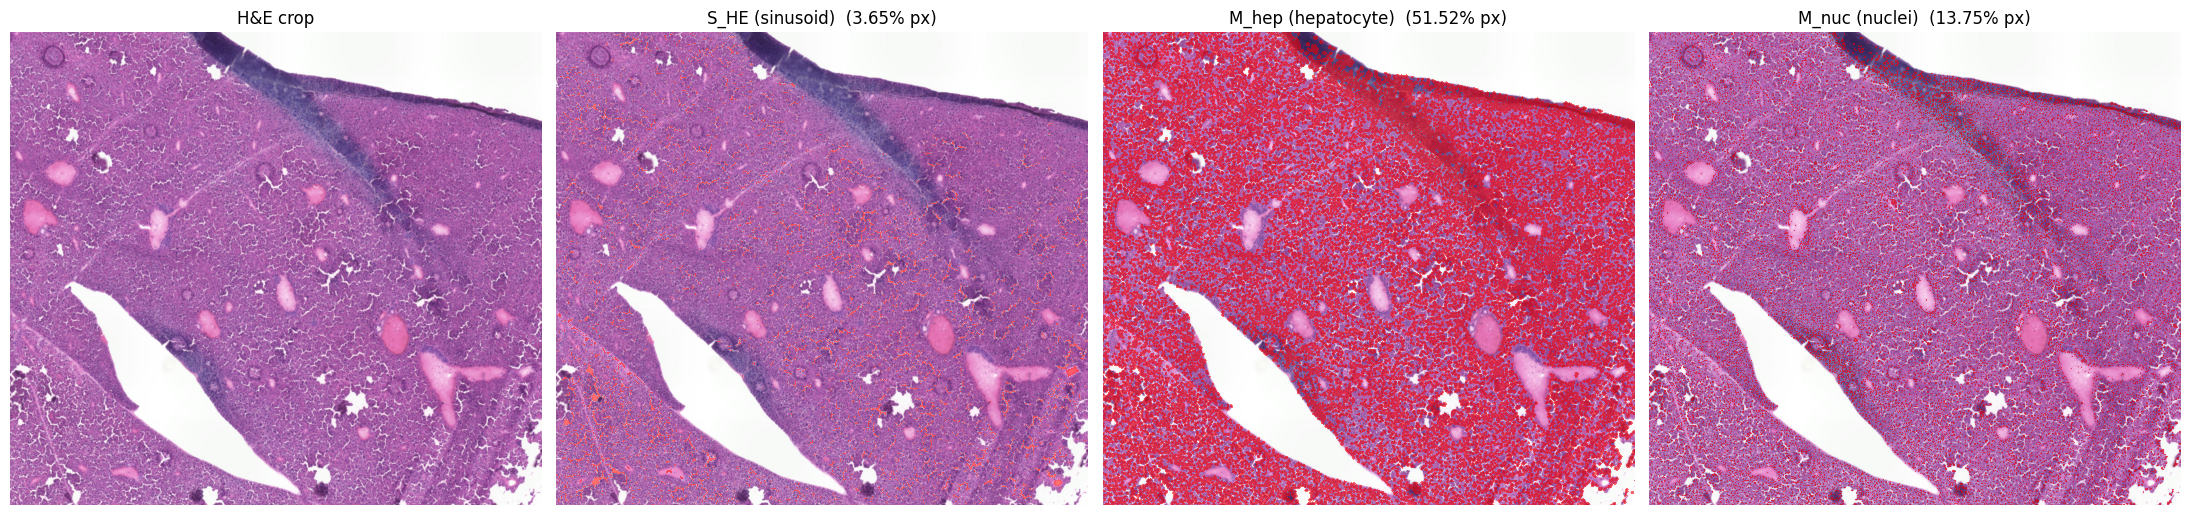

In [11]:
# QC: the H&E crop with each mask overlaid, all restricted to bbox.
he_crop = he_img[y_min:y_max, x_min:x_max]
panels = [("H&E crop", None), ("S_HE (sinusoid)", S_HE), ("M_hep (hepatocyte)", M_hep),
          ("M_nuc (nuclei)", M_nuc)]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
for ax, (title, m) in zip(axes, panels):
    ax.imshow(he_crop)
    if m is not None:
        ax.imshow(np.ma.masked_where(m[y_min:y_max, x_min:x_max] == 0,
                                     m[y_min:y_max, x_min:x_max]),
                  cmap="autumn", alpha=0.55, interpolation="nearest")
        ax.set_title(f"{title}  ({m[y_min:y_max, x_min:x_max].mean()*100:.2f}% px)")
    else:
        ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


## Chunk 6 — Wendland C² kernel & support radius ρ (Sec. 2.2)

Support radius tied to the MSI sampling geometry:
$$\rho=\frac{\sqrt{2}}{2}\,\operatorname{median}_{(i,j)\in E_4}\lVert T_0(u_i)-T_0(u_j)\rVert_2$$
where $E_4$ is the set of **axis-aligned** nearest-neighbour pairs on the original
rectangular MSI grid (spots whose integer $u$ coordinates differ by exactly 1 in $x$ or in
$y$). We take `d_MSI` to be that median $E_4$ spacing in H&E-pixel units — the same quantity
reused later for $\sigma_{\mathrm{bg}}=4d_{\mathrm{MSI}}$, $\sigma_{\mathrm{peak}}=0.5d_{\mathrm{MSI}}$
and $d_{\mathrm{match}}=d_{\mathrm{MSI}}$ — so $\rho=\tfrac{\sqrt2}{2}\,d_{\mathrm{MSI}}$.

Compactly supported Wendland $C^2$ kernel:
$$K_\rho(x)=\frac{1}{C_\rho}\Big(1-\tfrac{\lVert x\rVert_2}{\rho}\Big)_+^{4}\Big(4\tfrac{\lVert x\rVert_2}{\rho}+1\Big)$$
discretised on the integer pixel grid and normalised to sum 1 (discrete analogue of
$\int K_\rho=1$).

⚠️ **Difference from the previous notebooks:** their `_create_wendland_kernel` used
$(1-(r/\rho)^2)^4\,(4(r/\rho)^2+1)$ — the argument squared. The paper's kernel is linear in
$\lVert x\rVert_2/\rho$; this chunk implements the paper's form.

In [12]:
def msi_grid_e4_spacing(u: np.ndarray, T0: np.ndarray) -> float:
    """Median T0-space distance between axis-aligned MSI grid neighbours (E_4, Sec. 2.2).

    E_4 pairs are found with a KD-tree on the *original* integer MSI grid, where
    axis-aligned neighbours sit at distance exactly 1 and diagonals at sqrt(2);
    query_pairs(r=1.0) therefore returns exactly the horizontal/vertical pairs.
    Their separation is then measured in T0 (warped H&E) space.

    Args:
        u (np.ndarray): (n, 2) integer-valued MSI pixel coordinates u_i.
        T0 (np.ndarray): (n, 2) the same spots mapped into H&E pixel space by T0.

    Returns:
        d_MSI (float): median ||T0(u_i) - T0(u_j)|| over all E_4 pairs (H&E-pixel units).
    """
    pairs = cKDTree(u).query_pairs(r=1.0, output_type="ndarray")
    d = np.linalg.norm(T0[pairs[:, 0]] - T0[pairs[:, 1]], axis=1)
    return float(np.median(d))


def wendland_c2_kernel(rho: float) -> np.ndarray:
    """Discretised, sum-normalised Wendland C2 kernel K_rho (Sec. 2.2).

    Args:
        rho (float): support radius in pixels; the kernel is zero for ||x|| >= rho.

    Returns:
        K (np.ndarray): (2R+1, 2R+1) float64 kernel, R = ceil(rho), entries sum to 1.
    """
    R = int(np.ceil(rho))
    ax = np.arange(-R, R + 1)
    xx, yy = np.meshgrid(ax, ax)
    r = np.sqrt(xx ** 2 + yy ** 2) / rho          # ||x|| / rho
    K = np.zeros_like(r)
    inside = r < 1.0
    K[inside] = (1.0 - r[inside]) ** 4 * (4.0 * r[inside] + 1.0)
    K /= K.sum()
    return K


d_MSI (median E_4 spacing, H&E px) : 6.583
rho  (Wendland support, H&E px)    : 4.655
K_rho shape / sum                  : (11, 11) / 1.000000


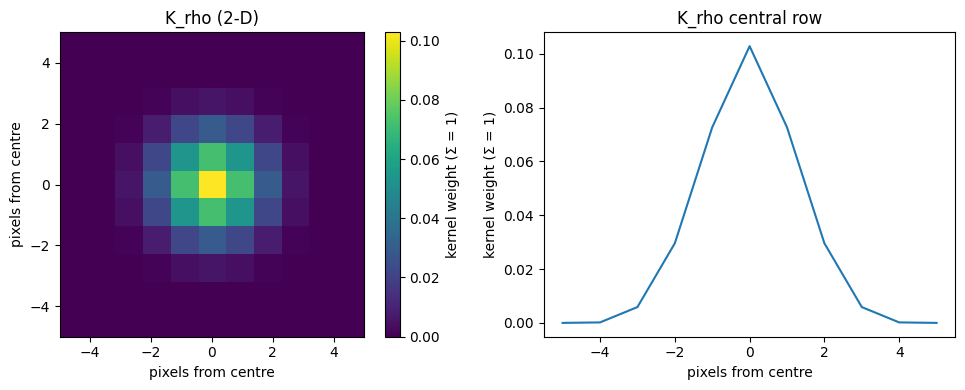

In [13]:
d_MSI = msi_grid_e4_spacing(u, T0)
rho = (np.sqrt(2.0) / 2.0) * d_MSI
K_rho = wendland_c2_kernel(rho)

print(f"d_MSI (median E_4 spacing, H&E px) : {d_MSI:.3f}")
print(f"rho  (Wendland support, H&E px)    : {rho:.3f}")
print(f"K_rho shape / sum                  : {K_rho.shape} / {K_rho.sum():.6f}")

# Both panels show K_rho itself (the averaging weights), not any tissue data.
# Weights are normalised to sum to 1 over the whole kernel.
mid = K_rho.shape[0] // 2                     # centre index; kernel spans -mid .. +mid px

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im = ax[0].imshow(K_rho, cmap="viridis", origin="lower",
                  extent=[-mid, mid, -mid, mid])
ax[0].set_title("K_rho (2-D)")
ax[0].set_xlabel("pixels from centre"); ax[0].set_ylabel("pixels from centre")
fig.colorbar(im, ax=ax[0], label="kernel weight (Σ = 1)")

ax[1].plot(np.arange(-mid, mid + 1), K_rho[mid])
ax[1].set_title("K_rho central row")
ax[1].set_xlabel("pixels from centre"); ax[1].set_ylabel("kernel weight (Σ = 1)")
plt.tight_layout(); plt.show()


## Chunk 7 — locally-normalised smooth H&E field f(z) (Sec. 2.2)

$$f(z)=\frac{(S_{\mathrm{HE}}*K_\rho)(z)}{(M*K_\rho)(z)}\quad\text{where the denominator is positive, else }f(z)=0$$

A Nadaraya–Watson-type local kernel average of the binary sinusoid mask, divided by the
locally available valid-mask mass so the estimate is not attenuated where the kernel hangs
off the edge of the valid region. Computed **once** on the `bbox` crop (both $S_{\mathrm{HE}}$
and $M$ are zero-padded outside it) and wrapped in a bilinear
`RegularGridInterpolator` so it can be evaluated at arbitrary transformed positions:
$$s_T=\big(f(T(u_i))\big)_{i\in\mathcal N}$$
The field `f_grid` and its interpolator `f_interp` are fixed for the rest of the pipeline —
only the query locations change (initial $T_0$, then the TPS-refined positions).

Per your choice, $M$ is the rectangular `bbox` mask from Chunk 5 (not a tissue segmentation),
so inside the crop the denominator is ≈ 1 and the normalisation only corrects the outer
5-pixel border.

Reuses `smooth_mask_normalized` from the previous notebooks, with `scipy.ndimage.convolve`
(C loop) in place of `scipy.signal.convolve2d` and the corrected `K_rho`.

In [14]:
def build_smooth_he_field(S_HE: np.ndarray, M: np.ndarray, K_rho: np.ndarray,
                          bbox: tuple):
    """Locally-normalised Wendland smoothing of S_HE, with a bilinear interpolator (Sec. 2.2).

    Args:
        S_HE (np.ndarray): (H, W) binary sinusoid mask on the full H&E canvas.
        M (np.ndarray): (H, W) valid-pixel mask on the full H&E canvas.
        K_rho (np.ndarray): (2R+1, 2R+1) Wendland C2 kernel, entries sum to 1.
        bbox (tuple): (y_min, y_max, x_min, x_max) crop f is computed on; both masks
            are treated as zero outside it.

    Returns:
        f_grid (np.ndarray): (y_max-y_min, x_max-x_min) float32 field f(z); 0 where the
            smoothed valid-mask mass is 0.
        f_interp (RegularGridInterpolator): bilinear sampler on H&E-pixel (row=y, col=x)
            coordinates; bounds_error=False, fill_value=0.0 for points outside the crop.
    """
    y0, y1, x0, x1 = bbox
    S = S_HE[y0:y1, x0:x1].astype(np.float64)
    Mc = M[y0:y1, x0:x1].astype(np.float64)

    num = ndi.convolve(S, K_rho, mode="constant", cval=0.0)      # (S_HE * K_rho)
    den = ndi.convolve(Mc, K_rho, mode="constant", cval=0.0)     # (M    * K_rho)

    f_grid = np.zeros_like(num, dtype=np.float32)
    ok = den > 0
    f_grid[ok] = (num[ok] / den[ok]).astype(np.float32)

    f_interp = RegularGridInterpolator(
        (np.arange(y0, y1), np.arange(x0, x1)), f_grid,
        method="linear", bounds_error=False, fill_value=0.0,
    )
    return f_grid, f_interp


def project_field(f_interp, P_xy: np.ndarray) -> np.ndarray:
    """Sample f at transformed positions: s_T = f(T(u_i)).

    Args:
        f_interp (RegularGridInterpolator): from build_smooth_he_field.
        P_xy (np.ndarray): (n, 2) H&E-pixel coordinates (x, y) = T(u_i).

    Returns:
        s_T (np.ndarray): (n,) float sampled field values, 0 outside the crop.
    """
    return f_interp(np.column_stack([P_xy[:, 1], P_xy[:, 0]]))   # -> (row=y, col=x)


f_grid shape        : (4613, 5180)
f range             : (0.0, 1.0)
f mean (nonzero)     : 0.40282052755355835
s_T0 range           : (0.0, 1.0)
s_T0 == 0 (outside f): 239302 / 269511


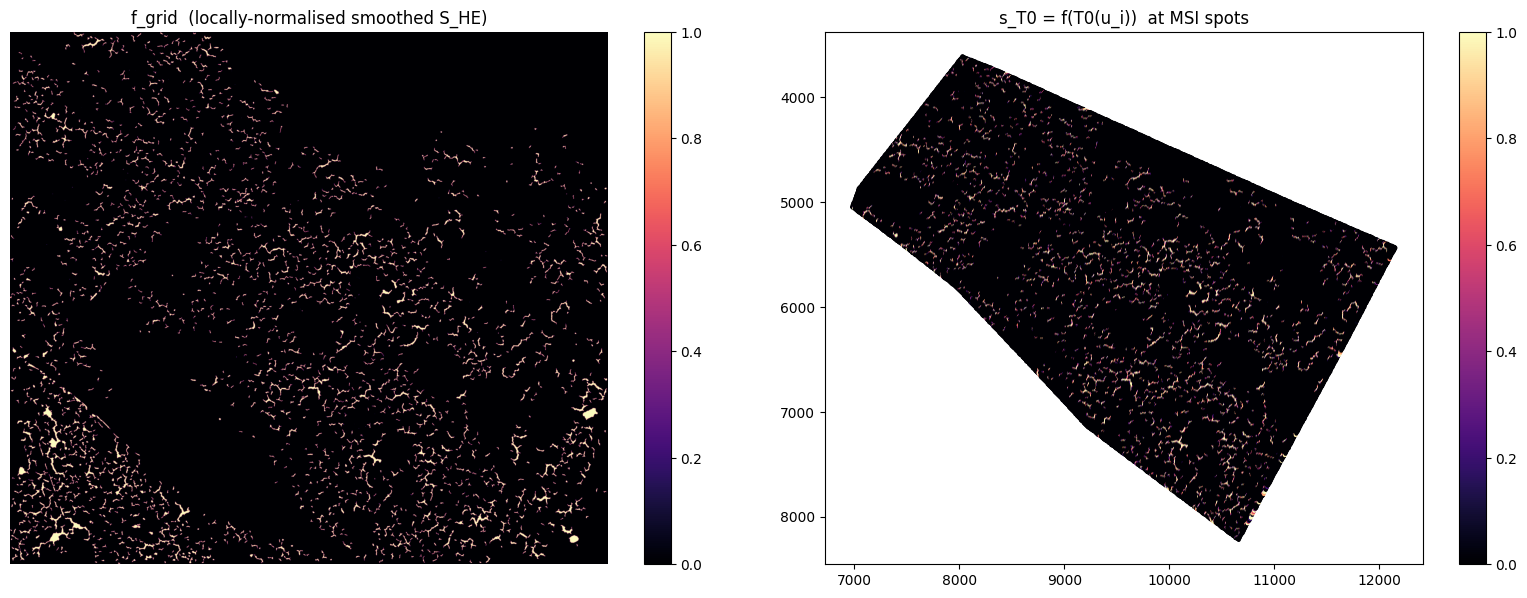

In [15]:
f_grid, f_interp = build_smooth_he_field(S_HE, M, K_rho, bbox)

# s_T0(i) = f(T0(u_i)) -- the anatomical target at the initial geometry (used from Chunk 8 on)
s_T0_preview = project_field(f_interp, T0)

print("f_grid shape        :", f_grid.shape)
print("f range             :", (float(f_grid.min()), float(f_grid.max())))
print("f mean (nonzero)     :", float(f_grid[f_grid > 0].mean()))
print("s_T0 range           :", (float(s_T0_preview.min()), float(s_T0_preview.max())))
print("s_T0 == 0 (outside f):", int((s_T0_preview == 0).sum()), "/", len(s_T0_preview))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
im = ax[0].imshow(f_grid, cmap="magma")
ax[0].set_title("f_grid  (locally-normalised smoothed S_HE)"); ax[0].axis("off")
fig.colorbar(im, ax=ax[0], fraction=0.046)
sc = ax[1].scatter(T0[:, 0], T0[:, 1], c=s_T0_preview, s=3, cmap="magma")
ax[1].set_title("s_T0 = f(T0(u_i))  at MSI spots"); ax[1].invert_yaxis(); ax[1].set_aspect("equal")
fig.colorbar(sc, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()


## Chunk 8 — anatomical target s_T₀ & the ridge metafeature fit (Sec. 2.3)

The initial target is $s_{T_0,i}=f(T_0(u_i))$ — this is the fixed one-dimensional anatomical
signal every metafeature is learned against.

`metafeature_fit(X_I, s_I)` implements Sec. 2.3 on an arbitrary spot subset $\mathcal I$:
$$(\hat\alpha_{\mathcal I},\hat\beta_{\mathcal I})=\arg\min_{\alpha,\beta}\ \frac{1}{|\mathcal I|}\lVert s_{T_0,\mathcal I}-\alpha\mathbf 1-X_{\mathcal I}\beta\rVert_2^2+\lambda_{\mathrm{ridge}}\lVert\beta\rVert_2^2,\qquad \lambda_{\mathrm{ridge}}=0.05$$
$$\hat w_{\mathcal I}=\hat\beta_{\mathcal I}/\lVert\hat\beta_{\mathcal I}\rVert_2,\qquad \operatorname{sign}\ \text{s.t.}\ \operatorname{cor}(X_{\mathcal I}\hat w_{\mathcal I},\,s_{T_0,\mathcal I})\ge 0$$

Implementation notes:
- The paper **averages the residual term** ($1/|\mathcal I|$) but **not** the ridge term;
  `sklearn.Ridge` minimises $\lVert\cdot\rVert_2^2+\alpha\lVert\beta\rVert_2^2$ (unaveraged),
  so we pass `alpha = |I| * LAMBDA_RIDGE` to reproduce the paper's scaling.
- Intercept $\alpha$ is unpenalised (`fit_intercept=True`) — it absorbs the target mean and
  any shift in feature means from restricting the globally-standardised $X$ to $\mathcal I$.
- Returns only the unit direction $\hat w_{\mathcal I}$; that is all Chunks 12–14 need.

This helper is reused for peri-fiducial radius selection (Chunk 12), the full-slide
$q^{(0)}=X\hat w^{(0)}$, and the TPS target.

In [16]:
def metafeature_fit(X_I: np.ndarray, s_I: np.ndarray, lam: float = LAMBDA_RIDGE) -> np.ndarray:
    """Ridge-regularised association of X onto a 1-D target -> unit direction (Sec. 2.3).

    Args:
        X_I (np.ndarray): (|I|, p) rows of the frozen standardised feature matrix for
            the spot subset I.
        s_I (np.ndarray): (|I|,) anatomical target values s_{T0} on the same subset.
        lam (float): ridge penalty lambda_ridge (paper-fixed 0.05). Passed to sklearn
            as alpha = |I| * lam so that sklearn's unaveraged SSE + alpha||beta||^2
            matches the paper's averaged (1/|I|)SSE + lam||beta||^2.

    Returns:
        w (np.ndarray): (p,) unit-norm metafeature direction \hat{w}_I, signed so that
            corr(X_I @ w, s_I) >= 0. Returns zeros if the ridge solution is degenerate.
    """
    n_I = len(s_I)
    model = Ridge(alpha=n_I * lam, fit_intercept=True)
    model.fit(X_I, s_I)

    beta = model.coef_
    nrm = np.linalg.norm(beta)
    if nrm == 0:
        return beta
    w = beta / nrm
    if np.corrcoef(X_I @ w, s_I)[0, 1] < 0:
        w = -w
    return w


In [17]:
# Anatomical target at the initial geometry (fixed 1-D signal, used from here on).
s_T0 = project_field(f_interp, T0)

# Sanity check only (NOT a pipeline step): a whole-slide fit shows the best cross-modal
# correlation the metafeature can reach before any peri-fiducial restriction / TPS.
_w_all = metafeature_fit(X, s_T0)
_q_all = X @ _w_all
print("whole-slide sanity fit:")
print("  ||w||                :", round(float(np.linalg.norm(_w_all)), 6))
print("  # non-zero coeffs     :", int((np.abs(_w_all) > 1e-8).sum()), "/", p)
print("  corr(X w, s_T0)       :", round(float(np.corrcoef(_q_all, s_T0)[0, 1]), 4))

whole-slide sanity fit:
  ||w||                : 1.0
  # non-zero coeffs     : 933 / 933
  corr(X w, s_T0)       : 0.3401


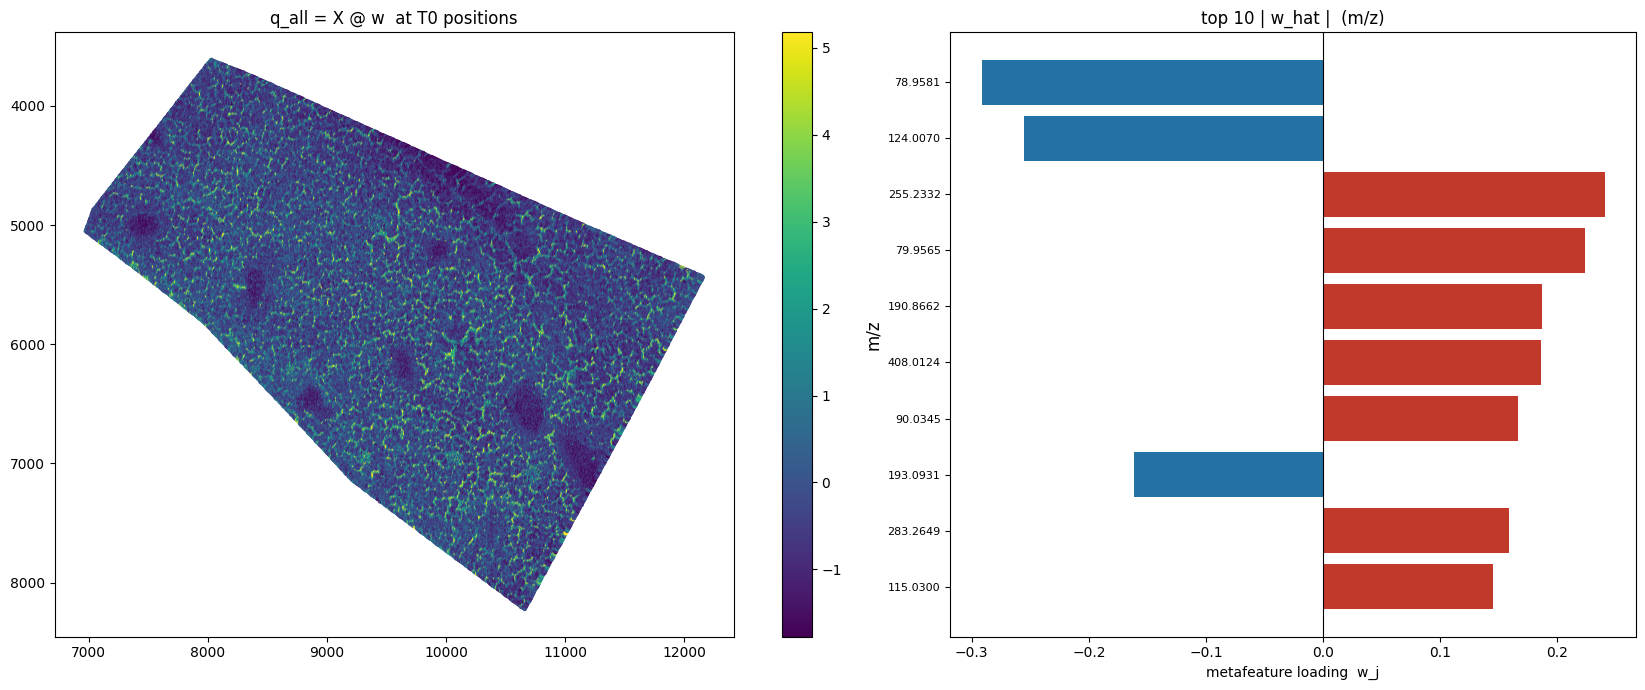

In [18]:
# QC: the whole-slide sanity metafeature in space, and its largest loadings.
TOP_N = 10
order = np.argsort(np.abs(_w_all))[::-1][:TOP_N]        # features by |coefficient|

fig, ax = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={"width_ratios": [1.4, 1]})

sc = ax[0].scatter(T0[:, 0], T0[:, 1], c=_q_all, s=4, cmap="viridis",
                   vmin=np.percentile(_q_all, 1), vmax=np.percentile(_q_all, 99))
ax[0].set_title("q_all = X @ w  at T0 positions"); ax[0].set_aspect("equal")
ax[0].invert_yaxis(); fig.colorbar(sc, ax=ax[0], fraction=0.046)

colors = ["#c0392b" if _w_all[i] > 0 else "#2471a3" for i in order]
ax[1].barh(range(TOP_N), _w_all[order][::-1], color=colors[::-1])
ax[1].set_yticks(range(TOP_N))
ax[1].set_yticklabels([f"{mz_labels[i]:.4f}" for i in order][::-1], fontsize=8)
ax[1].set_xlabel("metafeature loading  w_j"); ax[1].set_title(f"top {TOP_N} | w_hat |  (m/z)", fontsize=12)
ax[1].set_ylabel("m/z", fontsize=12)
ax[1].axvline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()


## Chunk 9 — peri-fiducial assignment (Sec. 2.4)

Each MSI spot is assigned to its nearest fiducial under the initial transform:
$$\kappa_i=\arg\min_{1\le k\le F}\lVert T_0(u_i)-h_k\rVert_2,\qquad d_i^{\mathrm{fid}}=\lVert T_0(u_i)-h_{\kappa_i}\rVert_2$$
Ownership $\kappa_i$ is computed **once here and never changes** — every candidate radius in
Chunks 10–12 sub-selects within these fixed fiducial territories, so folds belonging to
different fiducials stay disjoint even where geometric discs around the fiducials overlap.
$m_k=\lvert\{i:\kappa_i=k\}\rvert$ is the size of fiducial $k$'s complete territory.

Ties are resolved deterministically by `cKDTree.query` (lowest fiducial index on an exact
tie; exact ties are effectively impossible with float coordinates anyway).

In [19]:
def assign_peri_fiducial(T0: np.ndarray, he_fiducials: np.ndarray):
    """Nearest-fiducial ownership and distance for every spot (Sec. 2.4).

    Args:
        T0 (np.ndarray): (n, 2) spot positions in H&E pixel space under T0.
        he_fiducials (np.ndarray): (F, 2) fiducial coordinates h_k in H&E pixels.

    Returns:
        kappa (np.ndarray): (n,) int, index of the nearest fiducial for each spot.
        d_fid (np.ndarray): (n,) float, distance ||T0(u_i) - h_{kappa_i}||_2.
        m_k (np.ndarray): (F,) int, territory size m_k = #{i : kappa_i = k}.
    """
    d_fid, kappa = cKDTree(he_fiducials).query(T0, k=1)
    kappa = kappa.astype(int)
    m_k = np.bincount(kappa, minlength=len(he_fiducials))
    return kappa, d_fid, m_k


kappa, d_fid, m_k = assign_peri_fiducial(T0, he_fiducials)

print("F fiducials              :", len(he_fiducials))
print("territory sizes m_k       :", m_k.tolist())
print("  min / median / max      :", int(m_k.min()), int(np.median(m_k)), int(m_k.max()))
print("d_fid  (H&E px)  min/med/max:", round(float(d_fid.min()), 1),
      round(float(np.median(d_fid)), 1), round(float(d_fid.max()), 1))


F fiducials              : 16
territory sizes m_k       : [5192, 16986, 25151, 18384, 15070, 20176, 20520, 14079, 15588, 9272, 29022, 15433, 25660, 12318, 16279, 10381]
  min / median / max      : 5192 15933 29022
d_fid  (H&E px)  min/med/max: 1.0 388.3 1507.3


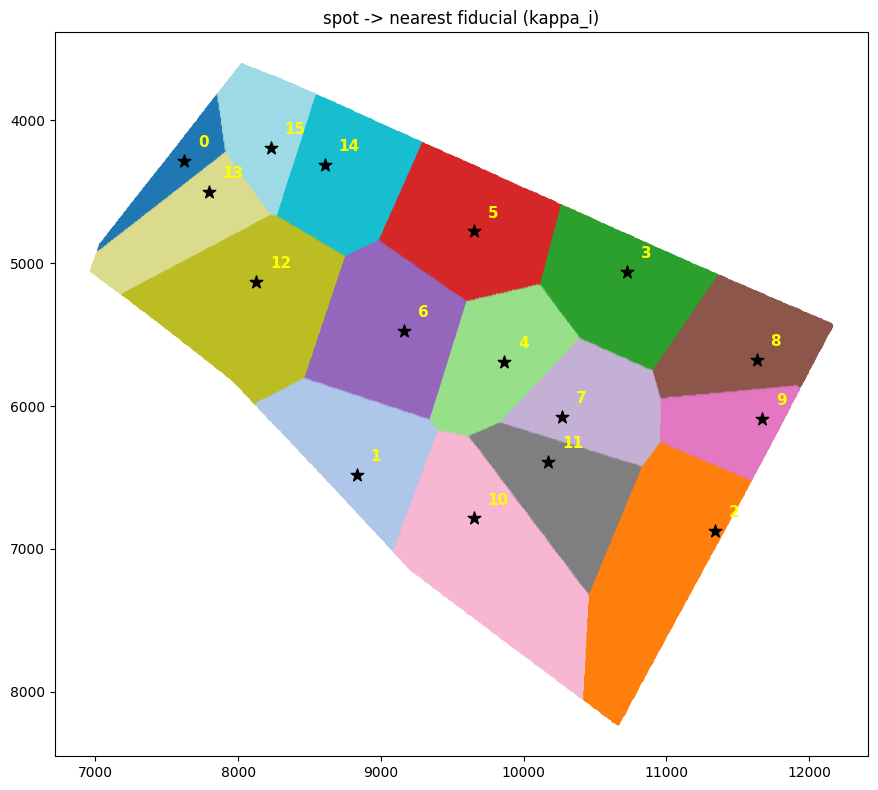

In [20]:
# QC: fiducial territories (Voronoi-like ownership).
fig, ax = plt.subplots(figsize=(9, 8))

ax.scatter(T0[:, 0], T0[:, 1], c=kappa, s=4, cmap="tab20")
ax.scatter(he_fiducials[:, 0], he_fiducials[:, 1], c="k", s=90, marker="*")
for k, (hx, hy) in enumerate(he_fiducials):
    ax.annotate(str(k), (hx, hy), xytext=(10, 10), textcoords="offset points",
                color="yellow", fontsize=11, fontweight="bold")
ax.set_title("spot -> nearest fiducial (kappa_i)")
ax.set_aspect("equal"); ax.invert_yaxis()
plt.tight_layout(); plt.show()


## Chunk 10 — balanced fiducial bipartitions (Sec. 2.4)

$B=10$ repeated splits $A_b\,\dot\cup\,B_b=\{1,\dots,F\}$, each built to balance the number
of assigned MSI spots while spreading both halves over the slide. Construction is
**independent of the candidate radius** — the same 10 splits are reused for every radius in
Chunk 12.

Per split:

1. seed $A_b$ and $B_b$ with one uniformly-random fiducial each (distinct);
2. while unassigned fiducials remain, add the next one to the half with the **smaller current
   territory size** $m_{A_b}=\sum_{k\in A_b}m_k$ vs $m_{B_b}$ (exact ties → $A_b$, per paper);
3. *which* remaining fiducial is added is drawn by a **k-means++ rule** — fiducial $k$ is
   sampled with probability $\propto w_C(k)=\min_{j\in C}\lVert h_k-h_j\rVert_2^2$, so added
   fiducials tend to sit far from those already in that half (spatial coverage).

Sampling uses `np.random.default_rng(BIPARTITION_SEED)` for reproducibility (the paper does
not fix a seed).

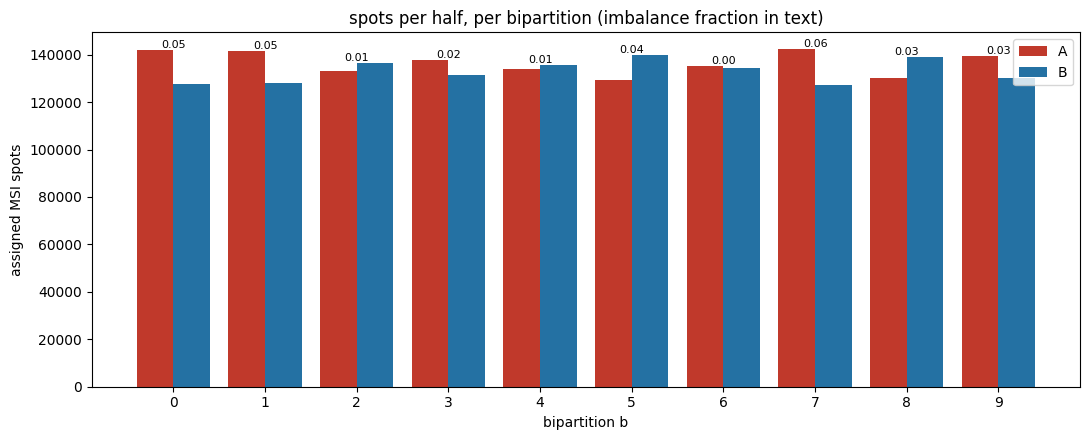

In [21]:
def balanced_bipartitions(he_fiducials: np.ndarray, m_k: np.ndarray,
                          B: int = N_BIPARTITIONS, seed: int = BIPARTITION_SEED):
    """B spatially-balanced fiducial bipartitions A_b, B_b (Sec. 2.4).

    Args:
        he_fiducials (np.ndarray): (F, 2) fiducial coordinates h_k.
        m_k (np.ndarray): (F,) territory sizes (MSI spots owned by each fiducial).
        B (int): number of bipartitions to generate.
        seed (int): RNG seed.

    Returns:
        splits (list[tuple[np.ndarray, np.ndarray]]): length B; each entry is
            (A_idx, B_idx) -- sorted, disjoint fiducial-index arrays whose union is
            range(F).
    """
    rng = np.random.default_rng(seed)
    F = len(he_fiducials)
    D2 = cdist(he_fiducials, he_fiducials) ** 2          # pairwise squared distances

    splits = []
    for _ in range(B):
        a0, b0 = rng.choice(F, size=2, replace=False)    # seed each half with one fiducial
        A, Bh = [int(a0)], [int(b0)]
        size_A, size_B = float(m_k[a0]), float(m_k[b0])
        remaining = set(range(F)) - {int(a0), int(b0)}

        while remaining:
            rem = np.array(sorted(remaining))            # sorted -> seed fully reproducible
            grow_A = size_A <= size_B                    # smaller half grows; exact ties -> A_b
            members = A if grow_A else Bh
            # w[k] = squared distance from candidate k to its nearest fiducial already in
            # that half; draw one candidate with probability proportional to w (k-means++)
            w = D2[np.ix_(rem, members)].min(axis=1)
            probs = w / w.sum() if w.sum() > 0 else np.full(len(rem), 1.0 / len(rem))
            k = int(rng.choice(rem, p=probs))
            if grow_A:
                A.append(k); size_A += m_k[k]
            else:
                Bh.append(k); size_B += m_k[k]
            remaining.discard(k)

        splits.append((np.array(sorted(A)), np.array(sorted(Bh))))
    return splits


splits = balanced_bipartitions(he_fiducials, m_k)

# per-split assigned-spot totals for the two halves
mA_all = np.array([int(m_k[A].sum()) for A, _ in splits])
mB_all = np.array([int(m_k[Bh].sum()) for _, Bh in splits])
bx = np.arange(len(splits))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(bx - 0.2, mA_all, width=0.4, color="#c0392b", label="A")
ax.bar(bx + 0.2, mB_all, width=0.4, color="#2471a3", label="B")
for i in bx:
    imb = abs(mA_all[i] - mB_all[i]) / (mA_all[i] + mB_all[i])
    ax.text(i, max(mA_all[i], mB_all[i]), f"{imb:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(bx); ax.set_xlabel("bipartition b"); ax.set_ylabel("assigned MSI spots")
ax.set_title("spots per half, per bipartition (imbalance fraction in text)")
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout(); plt.show()


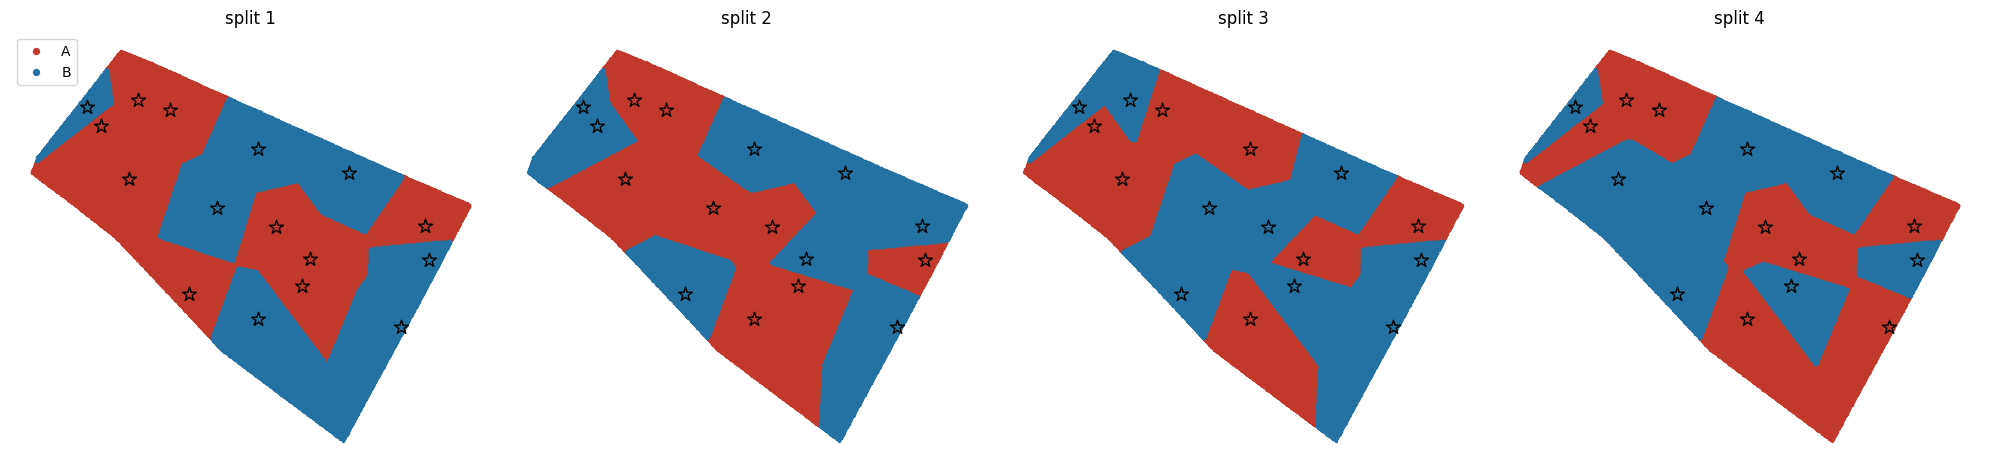

In [22]:
# QC: spatial layout of a few bipartitions -- each half should be spread across the slide,
# not clumped on one side.
show = min(4, len(splits))
fig, axes = plt.subplots(1, show, figsize=(5 * show, 5))
for ax, b in zip(np.atleast_1d(axes), range(show)):
    A, Bh = splits[b]
    in_A = np.isin(kappa, A)
    ax.scatter(T0[in_A, 0], T0[in_A, 1], s=2, c="#c0392b", label="A")
    ax.scatter(T0[~in_A, 0], T0[~in_A, 1], s=2, c="#2471a3", label="B")
    ax.scatter(he_fiducials[A, 0], he_fiducials[A, 1], c="#c0392b", s=110, marker="*", edgecolor="k")
    ax.scatter(he_fiducials[Bh, 0], he_fiducials[Bh, 1], c="#2471a3", s=110, marker="*", edgecolor="k")
    ax.set_title(f"split {b+1}"); ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")
axes[0].legend(markerscale=3, loc="upper left")
plt.tight_layout(); plt.show()


## Chunk 11 — candidate peri-fiducial radii (Sec. 2.4)

For a fiducial subset $A$ and radius $r$:
$$\mathcal I_A(r)=\{i:\kappa_i\in A,\ d_i^{\mathrm{fid}}\le r\},\quad n_A(r)=|\mathcal I_A(r)|,\quad v_A(r)=\operatorname{Var}\{s_{T_0,i}:i\in\mathcal I_A(r)\}$$

- **$r_{\min}$** — the smallest radius at which **both halves of every bipartition** satisfy
  $$n_A(r)\ge\max(3p,\ 0.05\,|\mathcal N|)\qquad\text{and}\qquad v_A(r)\ge\tfrac12 v_{\mathrm{all}}$$
  (first floor: a training sample with appreciably more spots than features and at least 5 %
  of all spots; second: excludes tiny regions where the anatomical target barely varies).
  These only bound the search range; they are never used as performance scores.
- **$r_{\max}=\max_i d_i^{\mathrm{fid}}$** — covers every valid MSI spot.
- **8 intermediate** empirical quantiles of $d_i^{\mathrm{fid}}$ lying strictly between
  $r_{\min}$ and $r_{\max}$.

The $r_{\min}$ search runs over a 400-point quantile grid of $d_i^{\mathrm{fid}}$ (a fine
discretisation of the "smallest radius" continuum); per half, $n_A$ and $v_A$ at every grid
radius are read off cumulative sums of the sorted $s_{T_0}$ values. `r_min` is taken as the
first grid radius where the conjunction holds across all 20 halves (`n_A` is monotone in
$r$; `v_A` is not, so in principle the conjunction could break and re-hold at larger $r$).


In [23]:
def compute_candidate_radii(kappa, d_fid, s_T0, splits, p, n_grid=400):
    """Candidate peri-fiducial radii r_min, r_max, and 8 intermediate quantiles (Sec. 2.4).

    Args:
        kappa (np.ndarray): (n,) nearest-fiducial index per spot.
        d_fid (np.ndarray): (n,) distance to the owning fiducial.
        s_T0 (np.ndarray): (n,) anatomical target f(T0(u_i)).
        splits (list[tuple[np.ndarray, np.ndarray]]): bipartitions (A_idx, B_idx) of
            fiducial indices.
        p (int): number of MSI features.
        n_grid (int): number of d_fid quantile points to search r_min over.

    Returns:
        radii (np.ndarray): sorted candidate radii = [r_min, 8 quantiles, r_max].
        r_min (float): smallest feasible radius (or r_max if none feasible).
        r_max (float): max_i d_fid_i.
        curves (dict): QC data -- 'r' (n_grid,), 'n' and 'v' each (2B, n_grid): one row
            per A/B half of each split, giving that half's spot count / target variance
            at each trial radius. Plus scalars 'n_thresh', 'v_thresh', 'v_all'.
    """
    n = len(d_fid)
    v_all = float(np.var(s_T0))                                  # whole-slide target spread
    n_thresh = max(MIN_SPOTS_FEATURE_MULT * p, MIN_SPOTS_SLIDE_FRAC * n)   # spot-count floor
    v_thresh = MIN_TARGET_VAR_FRAC * v_all                       # target-variance floor
    R = np.quantile(d_fid, np.linspace(0.0, 1.0, n_grid))        # ascending trial radii

    # For each A/B half of each split, build its n_A(r) and v_A(r) curve over R.
    # Trick: sort the half's spots by d_fid once; the first k of them ARE the spots within
    # radius r = k-th smallest d_fid, so cumulative sums of s_T0 / s_T0**2 give the prefix
    # mean and variance in O(1) per trial radius.
    n_rows, v_rows = [], []
    for A, Bh in splits:
        for fset in (A, Bh):
            m = np.isin(kappa, fset)                             # spots owned by this half
            order = np.argsort(d_fid[m])
            ds = d_fid[m][order]                                 # sorted distances
            s_sorted = s_T0[m][order]                            # target, same order
            cs, cs2 = np.cumsum(s_sorted), np.cumsum(s_sorted ** 2)
            k = np.searchsorted(ds, R, side="right")             # n_A(r): #spots with d_fid <= r
            idx = np.clip(k - 1, 0, None)
            with np.errstate(invalid="ignore", divide="ignore"):
                mean_k = np.where(k > 0, cs[idx] / k, np.nan)
                var_k = np.where(k > 0, cs2[idx] / k - mean_k ** 2, np.nan)   # v_A(r)
            n_rows.append(k.astype(float))
            v_rows.append(var_k)

    n_arr, v_arr = np.vstack(n_rows), np.vstack(v_rows)          # (2B, n_grid)
    all_ok = ((n_arr >= n_thresh) & (v_arr >= v_thresh)).all(axis=0)   # every half passes?
    r_max = float(d_fid.max())
    r_min = float(R[np.argmax(all_ok)]) if all_ok.any() else r_max     # first True radius

    mid = d_fid[(d_fid > r_min) & (d_fid < r_max)]
    q = np.quantile(mid, np.linspace(0.0, 1.0, 10)[1:-1]) if mid.size else np.array([])
    radii = np.unique(np.concatenate([[r_min], q, [r_max]]))
    curves = dict(r=R, n=n_arr, v=v_arr, n_thresh=n_thresh, v_thresh=v_thresh, v_all=v_all)
    return radii, r_min, r_max, curves


radii, r_min, r_max, rc = compute_candidate_radii(kappa, d_fid, s_T0, splits, p)

print(f"v_all      = {rc['v_all']:.5f}")
print(f"n_thresh   = {rc['n_thresh']:.0f}   (max(3p={3*p}, 0.05n={0.05*len(d_fid):.0f}))")
print(f"v_thresh   = {rc['v_thresh']:.5f}   (0.5 * v_all)")
print(f"r_min      = {r_min:.2f}   r_max = {r_max:.2f}")
print("candidate radii:", [round(float(x), 2) for x in radii])


v_all      = 0.02809
n_thresh   = 13476   (max(3p=2799, 0.05n=13476))
v_thresh   = 0.01404   (0.5 * v_all)
r_min      = 170.02   r_max = 1507.28
candidate radii: [170.02, 235.55, 291.88, 343.83, 394.02, 444.18, 500.37, 564.35, 683.73, 1507.28]


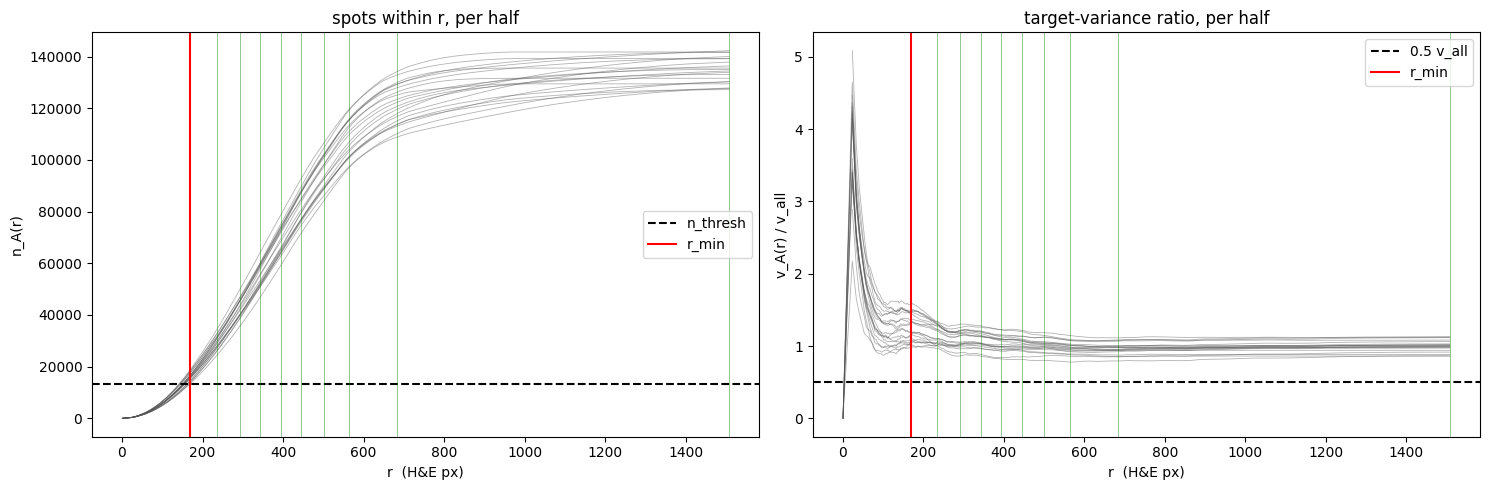

In [24]:
# QC: per-half n_A(r) and v_A(r)/v_all vs radius, with the feasibility thresholds,
# r_min (red) and every candidate radius (green).
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for row in rc["n"]:
    ax[0].plot(rc["r"], row, lw=0.6, alpha=0.45, color="#555")
ax[0].axhline(rc["n_thresh"], color="k", ls="--", label="n_thresh")
ax[0].set_xlabel("r  (H&E px)"); ax[0].set_ylabel("n_A(r)")
ax[0].set_title("spots within r, per half")

for row in rc["v"]:
    ax[1].plot(rc["r"], row / rc["v_all"], lw=0.6, alpha=0.45, color="#555")
ax[1].axhline(0.5, color="k", ls="--", label="0.5 v_all")
ax[1].set_xlabel("r  (H&E px)"); ax[1].set_ylabel("v_A(r) / v_all")
ax[1].set_title("target-variance ratio, per half")

for a in ax:
    for rr in radii:
        a.axvline(rr, color="green", lw=0.6, alpha=0.5)
    a.axvline(r_min, color="red", lw=1.5, label="r_min")
    a.legend()
plt.tight_layout(); plt.show()


## Chunk 12 — radius selection by split-set validation; freeze q⁽⁰⁾ (Sec. 2.5)

For each candidate radius $r$ and each bipartition $b$:

1. fit $\hat w_{A_b}(r)$ on $\mathcal I_{A_b}(r)$, score it on the *other* half's territory
   $$C^{(b)}_{A\to B}(r)=\operatorname{cor}\!\big(X_{\mathcal I_{B_b}(r)}\hat w_{A_b}(r),\ s_{T_0,\mathcal I_{B_b}(r)}\big)$$
   and symmetrically $C^{(b)}_{B\to A}(r)$;
2. combine the two directions on the Fisher scale
   $$Z_b(r)=\tfrac12\big\{\operatorname{atanh}C^{(b)}_{A\to B}(r)+\operatorname{atanh}C^{(b)}_{B\to A}(r)\big\}$$

Radius score: $C(r)=\tanh\big(\operatorname{median}_{b}Z_b(r)\big)$. With $C_{\max}=\max_r C(r)$,
select the **largest** $r$ with $C(r)\ge C_{\max}-0.01$ → $\hat r$ (the tolerance keeps more
tissue whenever held-out performance is practically tied).

Then $\mathcal I_{\mathrm{fid}}=\{i:d_i^{\mathrm{fid}}\le\hat r\}$ (union of all peri-fiducial
territories), and the **fixed** molecular pattern for all geometric optimisation:
$$\hat w^{(0)}=\text{metafeature\_fit}(X_{\mathcal I_{\mathrm{fid}}},\,s_{T_0,\mathcal I_{\mathrm{fid}}}),\qquad q^{(0)}=X\hat w^{(0)}$$
$q^{(0)}$ is **never re-fit** after this — Chunks 13–15 only move spot positions, not $q^{(0)}$.

This is the slowest chunk: ~`len(radii) * B * 2` ridge fits on peri-fiducial subsets.


In [25]:
def select_radius(kappa, d_fid, s_T0, X, splits, radii, tol=RADIUS_C_TOL):
    """Split-set validation of the peri-fiducial radius (Sec. 2.5).

    Args:
        kappa (np.ndarray): (n,) nearest-fiducial index per spot.
        d_fid (np.ndarray): (n,) distance to the owning fiducial.
        s_T0 (np.ndarray): (n,) anatomical target f(T0(u_i)).
        X (np.ndarray): (n, p) frozen standardised feature matrix.
        splits (list[tuple[np.ndarray, np.ndarray]]): bipartitions (A_idx, B_idx).
        radii (np.ndarray): candidate radii from compute_candidate_radii.
        tol (float): keep the largest r with C(r) >= C_max - tol.

    Returns:
        r_hat (float): selected radius.
        C_of_r (np.ndarray): (len(radii),) validation score C(r).
        C_max (float): max_r C(r).
        Zb_of_r (np.ndarray): (len(radii), B) per-split Fisher scores Z_b(r) (NaN where a
            half had < 2 spots at that radius).
    """
    def terr(fset, r):                                   # peri-fiducial territory I_A(r)
        return np.where(np.isin(kappa, fset) & (d_fid <= r))[0]

    def atanh_c(a, b):                                   # corr(X_a @ fit(X_b), s_a), Fisher
        w = metafeature_fit(X[b], s_T0[b])
        c = np.corrcoef(X[a] @ w, s_T0[a])[0, 1]
        return np.arctanh(np.clip(c, -0.999999, 0.999999))

    C_of_r, Zb_of_r = [], []
    for r in radii:
        Zb = []
        for A, Bh in splits:
            iA, iB = terr(A, r), terr(Bh, r)
            if len(iA) < 2 or len(iB) < 2:
                Zb.append(np.nan); continue
            Zb.append(0.5 * (atanh_c(iB, iA) + atanh_c(iA, iB)))   # A->B and B->A
        Zb = np.asarray(Zb)
        C_of_r.append(np.tanh(np.nanmedian(Zb)))
        Zb_of_r.append(Zb)

    C_of_r = np.asarray(C_of_r)
    C_max = float(np.nanmax(C_of_r))
    ok = np.where(C_of_r >= C_max - tol)[0]
    r_hat = float(radii[ok.max()])                       # largest tied radius
    return r_hat, C_of_r, C_max, np.asarray(Zb_of_r)


r_hat, C_of_r, C_max, Zb_of_r = select_radius(kappa, d_fid, s_T0, X, splits, radii)

# I_fid: union of all peri-fiducial territories at r_hat == every spot within r_hat
I_fid = np.where(d_fid <= r_hat)[0]

# fixed molecular pattern for all geometric optimisation
w0 = metafeature_fit(X[I_fid], s_T0[I_fid])
q0 = X @ w0

print(f"C_max = {C_max:.4f}   r_hat = {r_hat:.2f}   (of candidates {[round(float(x),1) for x in radii]})")
print(f"C(r): {[round(float(c), 4) for c in C_of_r]}")
print(f"|I_fid| = {len(I_fid)}  ({100*len(I_fid)/len(d_fid):.1f}% of spots)")
print(f"corr(q0, s_T0)  on I_fid : {np.corrcoef(q0[I_fid], s_T0[I_fid])[0,1]:.4f}")
print(f"corr(q0, s_T0)  whole slide: {np.corrcoef(q0, s_T0)[0,1]:.4f}")


C_max = 0.3092   r_hat = 1507.28   (of candidates [170.0, 235.5, 291.9, 343.8, 394.0, 444.2, 500.4, 564.4, 683.7, 1507.3])
C(r): [0.2703, 0.2786, 0.2825, 0.2964, 0.3012, 0.3059, 0.3027, 0.3014, 0.3028, 0.3092]
|I_fid| = 269511  (100.0% of spots)
corr(q0, s_T0)  on I_fid : 0.3401
corr(q0, s_T0)  whole slide: 0.3401


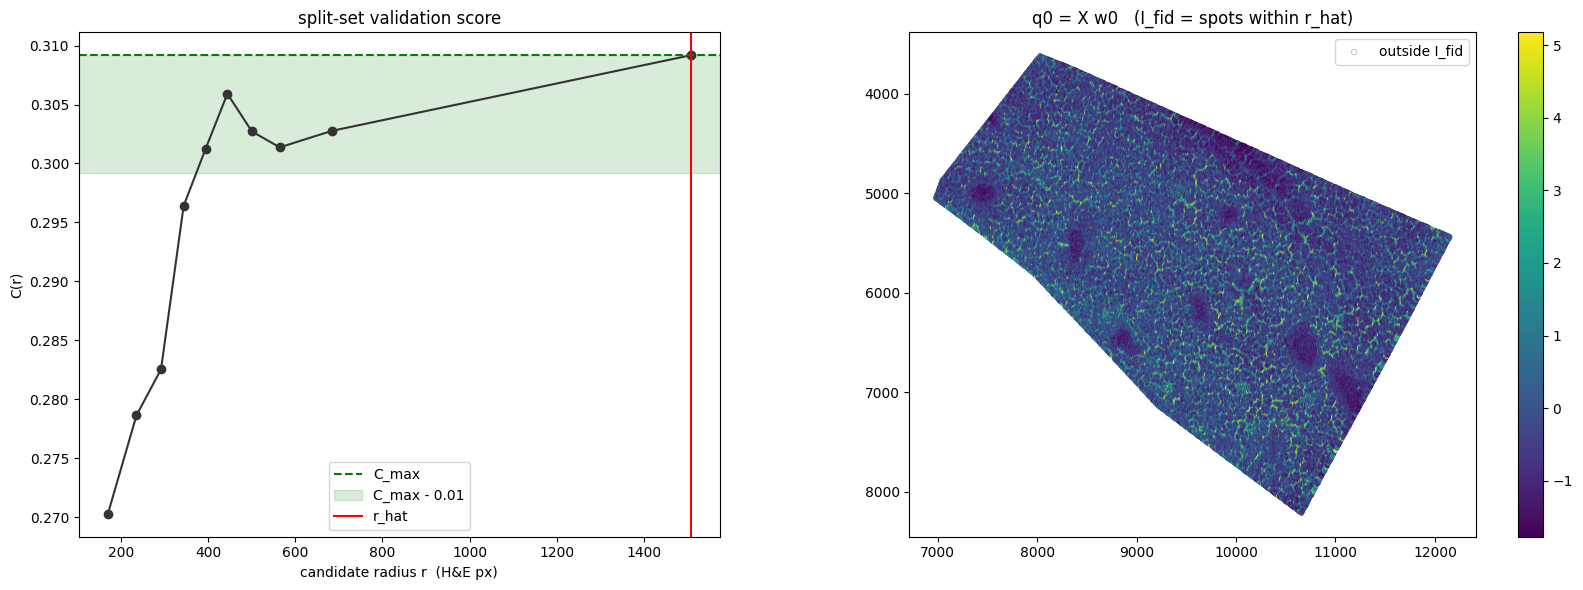

In [26]:
# QC: C(r) vs radius (with C_max, the tolerance band, r_hat), and q0 in space.
fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.3]})

ax[0].plot(radii, C_of_r, "o-", color="#333")
ax[0].axhline(C_max, color="green", ls="--", label="C_max")
ax[0].axhspan(C_max - RADIUS_C_TOL, C_max, color="green", alpha=0.15, label=f"C_max - {RADIUS_C_TOL}")
ax[0].axvline(r_hat, color="red", lw=1.5, label="r_hat")
ax[0].set_xlabel("candidate radius r  (H&E px)"); ax[0].set_ylabel("C(r)")
ax[0].set_title("split-set validation score"); ax[0].legend()

sc = ax[1].scatter(T0[:, 0], T0[:, 1], c=q0, s=4, cmap="viridis",
                   vmin=np.percentile(q0, 1), vmax=np.percentile(q0, 99))
inside = np.isin(np.arange(len(d_fid)), I_fid)
ax[1].scatter(T0[~inside, 0], T0[~inside, 1], s=4, facecolors="none",
              edgecolors="k", linewidths=0.15, label="outside I_fid")
ax[1].set_title(f"q0 = X w0   (I_fid = spots within r_hat)")
ax[1].set_aspect("equal"); ax[1].invert_yaxis(); ax[1].legend(markerscale=2)
fig.colorbar(sc, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

testing to see what the radii disk plot would look like when not the largest radii is chosen (for my own curiosity)

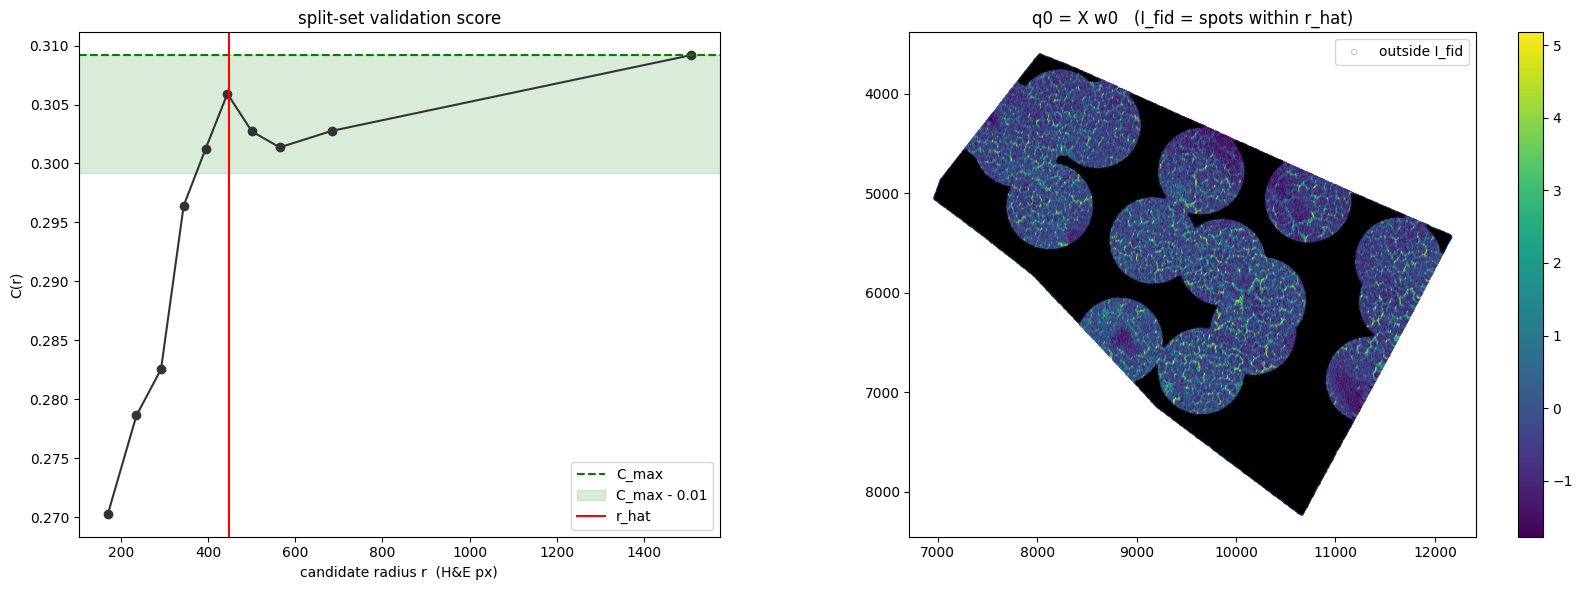

In [27]:
r_hat_new = 446.9
I_fid = np.where(d_fid <= r_hat_new)[0]
# QC: C(r) vs radius (with C_max, the tolerance band, r_hat), and q0 in space.
fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.3]})

ax[0].plot(radii, C_of_r, "o-", color="#333")
ax[0].axhline(C_max, color="green", ls="--", label="C_max")
ax[0].axhspan(C_max - RADIUS_C_TOL, C_max, color="green", alpha=0.15, label=f"C_max - {RADIUS_C_TOL}")
ax[0].axvline(r_hat_new, color="red", lw=1.5, label="r_hat")
ax[0].set_xlabel("candidate radius r  (H&E px)"); ax[0].set_ylabel("C(r)")
ax[0].set_title("split-set validation score"); ax[0].legend()

sc = ax[1].scatter(T0[:, 0], T0[:, 1], c=q0, s=4, cmap="viridis",
                   vmin=np.percentile(q0, 1), vmax=np.percentile(q0, 99))
inside = np.isin(np.arange(len(d_fid)), I_fid)
ax[1].scatter(T0[~inside, 0], T0[~inside, 1], s=4, facecolors="none",
              edgecolors="k", linewidths=0.15, label="outside I_fid")
ax[1].set_title(f"q0 = X w0   (I_fid = spots within r_hat)")
ax[1].set_aspect("equal"); ax[1].invert_yaxis(); ax[1].legend(markerscale=2)
fig.colorbar(sc, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

## Chunk 13 — thin-plate-spline basis (Sec. 2.6)

$$T_1(u)=T_0(u)+\widehat\Delta^{\mathrm{TPS}}(u),\qquad \Delta_\ell^{\mathrm{TPS}}(u)=\sum_{k=1}^{K}\theta_{k\ell}\,\phi(\lVert u-c_k\rVert_2),\quad \phi(r)=r^2\log r,\ \ \phi(0)=0$$

- Centres $c_k$ on a **coarse square Cartesian grid in the original MSI coordinate system**,
  single integer spacing $d_{\mathrm{TPS}}$ (MSI-pixel units) = smallest integer with
  $(\lceil W/d_{\mathrm{TPS}}\rceil+1)(\lceil H/d_{\mathrm{TPS}}\rceil+1)\le K_{\max}=150$;
  grid centred on the MSI bounding box (outer centres may fall just outside it). Regular and
  coarse **by design** — it must not adapt to local tissue irregularity.
- **No affine term.** The affine null space of the radial basis is removed by three side
  constraints per axis: $\sum_k\theta_{k\ell}=0$, $\sum_k\theta_{k\ell}c_{k,1}=0$,
  $\sum_k\theta_{k\ell}c_{k,2}=0$. Implemented by optimising $\theta_\ell=N\alpha_\ell$ where
  $N$ is an orthonormal basis of $\ker(P^\top)$, $P=[\mathbf 1\;c_x\;c_y]$ — any such
  $\theta$ satisfies all three automatically.
- $K_{\mathrm{TPS}}\in\mathbb R^{K\times K}$, $K_{\mathrm{TPS},jk}=\phi(\lVert c_j-c_k\rVert_2)$;
  bending energy $E_{\mathrm{bend}}(\Delta^{\mathrm{TPS}})=\operatorname{tr}(\Theta^\top K_{\mathrm{TPS}}\Theta)$
  (used in Chunk 14).
- `Phi_tps` $\in\mathbb R^{n\times K}$, $\phi(\lVert u_i-c_k\rVert_2)$ at every spot — stored
  here; the paper allows block evaluation for very large slides.

⚠️ **Difference from the previous notebook:** it built the grid in $T_0$ / H&E space and used
`floor` in the centre-count formula. This chunk follows the paper: grid and basis are in `u`
(MSI-pixel) space with the `ceil` formula. The coefficients $\Theta$ absorb the unit
conversion, so $\Delta^{\mathrm{TPS}}(u_i)$ is still an H&E-pixel correction added to
$T_0(u_i)$ in Chunk 14.

Reuses `tps_kernel` / `build_tps_basis` / `tps_nullspace` from the previous notebook.


In [28]:
from scipy.linalg import null_space


def tps_kernel(r: np.ndarray) -> np.ndarray:
    """Classical thin-plate radial basis phi(r) = r^2 log r, with phi(0) = 0.

    Args:
        r (np.ndarray): array of non-negative radii.

    Returns:
        np.ndarray: phi(r), same shape as r.
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(r > 0, r ** 2 * np.log(r), 0.0)


def build_tps_grid(u: np.ndarray, k_max: int = TPS_MAX_CENTRES) -> tuple:
    """Coarse square TPS centre grid in the original MSI coordinate system (Sec. 2.6).

    Args:
        u (np.ndarray): (n, 2) original MSI pixel coordinates.
        k_max (int): centre budget K_max.

    Returns:
        centres (np.ndarray): (K, 2) grid centres c_k in MSI-pixel units, K <= k_max.
        d_tps (int): integer grid spacing in MSI-pixel units.
        (Kx, Ky) (tuple[int, int]): grid dimensions, Kx * Ky = K.
    """
    x0, x1 = u[:, 0].min(), u[:, 0].max()
    y0, y1 = u[:, 1].min(), u[:, 1].max()
    W, H = x1 - x0, y1 - y0

    d_tps = 1
    while (np.ceil(W / d_tps) + 1) * (np.ceil(H / d_tps) + 1) > k_max:
        d_tps += 1

    Kx = int(np.ceil(W / d_tps)) + 1
    Ky = int(np.ceil(H / d_tps)) + 1
    xc, yc = 0.5 * (x0 + x1), 0.5 * (y0 + y1)
    xs = xc + (np.arange(Kx) - (Kx - 1) / 2) * d_tps        # centred on the bbox
    ys = yc + (np.arange(Ky) - (Ky - 1) / 2) * d_tps
    CX, CY = np.meshgrid(xs, ys)
    return np.column_stack([CX.ravel(), CY.ravel()]), int(d_tps), (Kx, Ky)


def build_tps_basis(centres: np.ndarray, query: np.ndarray) -> tuple:
    """TPS design matrices for the purely-radial basis (Sec. 2.6).

    Args:
        centres (np.ndarray): (K, 2) TPS centres c_k (MSI-pixel units).
        query (np.ndarray): (n, 2) points to evaluate the basis at (the MSI spots u_i).

    Returns:
        K_tps (np.ndarray): (K, K) phi(||c_j - c_k||) -- bending-energy kernel.
        P (np.ndarray): (K, 3) affine design [1, c_x, c_y] -- for the null-space constraints
            only; never added as an affine term to the field.
        Phi (np.ndarray): (n, K) phi(||u_i - c_k||) -- the basis at every spot.
    """
    K_tps = tps_kernel(cdist(centres, centres))
    P = np.column_stack([np.ones(len(centres)), centres])
    Phi = tps_kernel(cdist(query, centres))
    return K_tps, P, Phi


def tps_nullspace(P: np.ndarray) -> np.ndarray:
    """Orthonormal basis N of ker(P^T): theta = N @ alpha satisfies the 3 side constraints.

    Args:
        P (np.ndarray): (K, 3) affine design matrix at the centres.

    Returns:
        N (np.ndarray): (K, K - 3) with orthonormal columns; P.T @ (N @ alpha) == 0 for any
            alpha, so optimising over alpha explores exactly the constrained theta set.
    """
    return null_space(P.T)


In [29]:
C_tps, d_TPS, (Kx, Ky) = build_tps_grid(u)
# Build the RBF in grid-spacing units (coords / d_TPS): keeps phi(r)=r^2 log r values
# O(1..1e3) instead of O(1e7), so the optimiser is well conditioned. Theta absorbs the
# scale -- Delta_TPS = Phi @ theta is still an H&E-pixel correction.
K_tps, P_tps, Phi_tps = build_tps_basis(C_tps / d_TPS, u / d_TPS)
N_tps = tps_nullspace(P_tps)
K = C_tps.shape[0]

print(f"d_TPS           = {d_TPS}  (MSI px)")
print(f"grid            = {Kx} x {Ky}  ->  K = {K}  (<= {TPS_MAX_CENTRES})")
print(f"K_tps           : {K_tps.shape}")
print(f"Phi_tps         : {Phi_tps.shape}   ({Phi_tps.nbytes / 1e6:.0f} MB)")
print(f"  max |Phi|      : {np.abs(Phi_tps).max():.3e}   (grid-spacing units)")
print(f"N_tps           : {N_tps.shape}   (free params per axis = {N_tps.shape[1]})")
print(f"constraint check |P^T N| = {np.abs(P_tps.T @ N_tps).max():.2e}")


d_TPS           = 72  (MSI px)
grid            = 12 x 11  ->  K = 132  (<= 150)
K_tps           : (132, 132)
Phi_tps         : (269511, 132)   (285 MB)
  max |Phi|      : 4.511e+02   (grid-spacing units)
N_tps           : (132, 129)   (free params per axis = 129)
constraint check |P^T N| = 6.46e-15


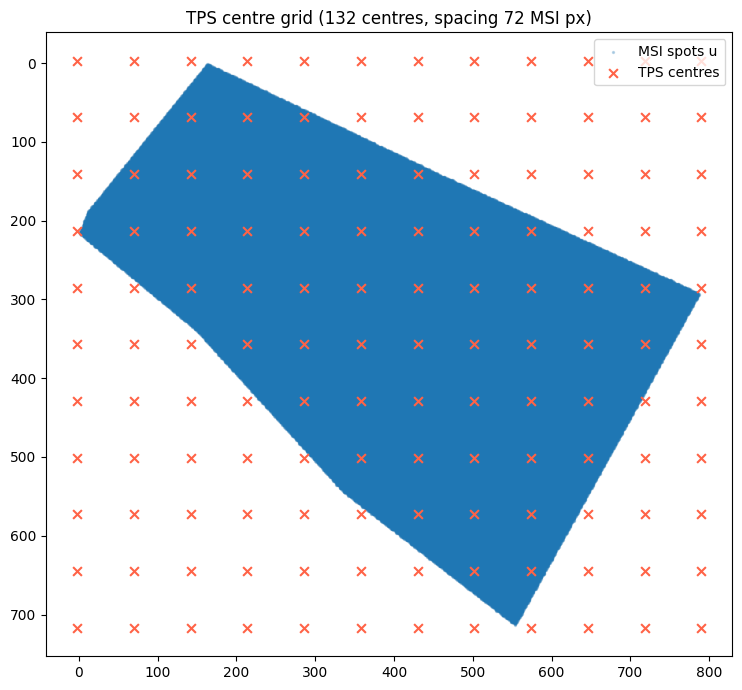

In [30]:
# QC: TPS centre grid over the MSI point cloud.
plt.figure(figsize=(8, 7))
plt.scatter(u[:, 0], u[:, 1], s=2, alpha=0.25, label="MSI spots u")
plt.scatter(C_tps[:, 0], C_tps[:, 1], c="tomato", marker="x", s=40, label="TPS centres")
plt.title(f"TPS centre grid ({K} centres, spacing {d_TPS} MSI px)")
plt.gca().set_aspect("equal"); plt.gca().invert_yaxis(); plt.legend()
plt.tight_layout(); plt.show()


## Chunk 14 — fit the smooth TPS; calibrate λ_TPS; produce T₁ (Sec. 2.6)

**Inner fit** (fixed $\lambda_{\mathrm{TPS}}$): maximise
$$\operatorname{cor}\!\big(q^{(0)},\,s_{T_0+\Delta^{\mathrm{TPS}}}\big)-\lambda_{\mathrm{TPS}}\,E_{\mathrm{bend}}(\Delta^{\mathrm{TPS}}),\qquad E_{\mathrm{bend}}=\operatorname{tr}(\Theta^\top K_{\mathrm{TPS}}\Theta)$$
over free parameters $\alpha$ (with $\theta_\ell=N\alpha_\ell$, so the three side constraints
hold automatically), by **unbounded** L-BFGS-B with an analytic gradient, initialised at
$\alpha=0$. The paper's argmax has no box constraint beyond the side constraints; the RBF is
built in grid-spacing units (Chunk 13) so the problem is well conditioned without one.
$q^{(0)}$ is the frozen molecular pattern from Chunk 12; $s_{T_0+\Delta}=f$ sampled bilinearly
at the displaced spot positions.

**λ calibration** ($\lambda_{\mathrm{TPS}}=2^k$, integer $k$): with
$$D_{\mathrm{fid}}(k)=\operatorname{median}\big\{\lVert\widehat\Delta^{\mathrm{TPS},(k)}(u_i)\rVert_2/d_{\mathrm{MSI}}:i\in\mathcal I_{\mathrm{fid}}\big\}\ \text{(MSI-pixel units)}$$
pick the **weakest** regularisation (smallest $k$) with $D_{\mathrm{fid}}(k)\le 1$. Search
starts at $k=0$: if it passes, step $k$ down until it first fails and keep the last passing
$k$; if it fails at $k=0$, step $k$ up until it first passes. Then
$T_1(u_i)=T_0(u_i)+\widehat\Delta^{\mathrm{TPS}}(u_i)$ — the final transform for this notebook
(no tear step).

Reuses the previous notebook's L-BFGS-B + analytic-gradient optimiser (bounds dropped).


In [31]:
def sample_grid(grid: np.ndarray, P_xy: np.ndarray, bbox: tuple, order: int = 1) -> np.ndarray:
    """Bilinearly sample a bbox-cropped grid at H&E-pixel coordinates P (x, y).

    Args:
        grid (np.ndarray): 2-D array defined on the bbox crop (row=y-y_min, col=x-x_min).
        P_xy (np.ndarray): (m, 2) query coordinates (x, y) in full-slide H&E pixels.
        bbox (tuple): (y_min, y_max, x_min, x_max).
        order (int): spline order for map_coordinates (1 = bilinear).

    Returns:
        np.ndarray: (m,) sampled values; 0 for points outside the crop.
    """
    y0, _, x0, _ = bbox
    return ndi.map_coordinates(grid, [P_xy[:, 1] - y0, P_xy[:, 0] - x0],
                               order=order, mode="constant", cval=0.0)


def build_field_gradients(f_grid: np.ndarray) -> tuple:
    """Spatial gradient of the smoothed H&E field, for the TPS analytic gradient.

    Args:
        f_grid (np.ndarray): the field f(z) on the bbox crop (from Chunk 7).

    Returns:
        dfdx (np.ndarray): d f / d x on the crop (float64).
        dfdy (np.ndarray): d f / d y on the crop (float64).
    """
    g = f_grid.astype(np.float64)
    dfdy, dfdx = np.gradient(g)                 # np.gradient returns (d/axis0=y, d/axis1=x)
    return dfdx, dfdy


In [32]:
def tps_objective_and_grad(alpha, N, Phi, T0, q0, f64, dfdx, dfdy, bbox, K_tps, lam):
    """Negative TPS objective and its analytic gradient (for minimize(jac=True)).

    Args:
        alpha (np.ndarray): (2r,) free parameters [alpha_x; alpha_y], r = N.shape[1].
        N (np.ndarray): (K, r) null-space basis; theta_l = N @ alpha_l.
        Phi (np.ndarray): (n, K) TPS basis at the MSI spots.
        T0 (np.ndarray): (n, 2) initial spot positions in H&E pixels.
        q0 (np.ndarray): (n,) frozen molecular pattern.
        f64 (np.ndarray): smoothed H&E field on the bbox crop, float64.
        dfdx, dfdy (np.ndarray): spatial gradient of f64 on the crop.
        bbox (tuple): (y_min, y_max, x_min, x_max).
        K_tps (np.ndarray): (K, K) bending-energy kernel.
        lam (float): lambda_TPS.

    Returns:
        val (float): -(corr - lam * E_bend).
        grad (np.ndarray): (2r,) gradient of val w.r.t. alpha.
    """
    r = N.shape[1]
    ax_, ay_ = alpha[:r], alpha[r:]
    tx, ty = N @ ax_, N @ ay_
    delta = np.column_stack([Phi @ tx, Phi @ ty])          # Delta^TPS(u_i), H&E px
    P = T0 + delta
    s = sample_grid(f64, P, bbox)

    qc, sc = q0 - q0.mean(), s - s.mean()
    nq, ns = np.linalg.norm(qc), np.linalg.norm(sc)
    corr = (qc @ sc) / (nq * ns)
    Eb = tx @ K_tps @ tx + ty @ K_tps @ ty
    val = -(corr - lam * Eb)

    # d(-corr)/ds_i, then chain through the bilinear field gradient and Phi, N
    dval_ds = -(qc / (nq * ns) - corr * sc / (ns ** 2))
    sx = sample_grid(dfdx, P, bbox)
    sy = sample_grid(dfdy, P, bbox)
    gx = Phi.T @ (dval_ds * sx) + lam * 2.0 * (K_tps @ tx)
    gy = Phi.T @ (dval_ds * sy) + lam * 2.0 * (K_tps @ ty)
    grad = np.concatenate([N.T @ gx, N.T @ gy])
    return val, grad


In [33]:
def fit_tps(lam, N, Phi, T0, q0, f64, dfdx, dfdy, bbox, K_tps, maxiter=200):
    """One TPS fit at fixed lambda (Sec. 2.6), unbounded L-BFGS-B + analytic gradient.

    Args:
        lam (float): lambda_TPS.
        N, Phi, T0, q0, f64, dfdx, dfdy, bbox, K_tps: see tps_objective_and_grad.
        maxiter (int): L-BFGS-B iteration budget.

    Returns:
        res (OptimizeResult): the scipy result (res.x is used regardless of success).
        delta (np.ndarray): (n, 2) fitted displacement Delta^TPS(u_i) in H&E px.
        theta (tuple[np.ndarray, np.ndarray]): (theta_x, theta_y), the RBF coefficients.
    """
    r = N.shape[1]
    res = optimize.minimize(
        tps_objective_and_grad, np.zeros(2 * r),
        args=(N, Phi, T0, q0, f64, dfdx, dfdy, bbox, K_tps, lam),
        method="L-BFGS-B", jac=True,
        options={"maxiter": maxiter},
    )
    tx, ty = N @ res.x[:r], N @ res.x[r:]
    delta = np.column_stack([Phi @ tx, Phi @ ty])
    return res, delta, (tx, ty)


In [34]:
def select_lambda_tps(I_fid, d_MSI, fit_kwargs, k_start=0, k_lo=-12, k_hi=24):
    """Pick k for lambda_TPS = 2**k by the D_fid(k) <= 1 MSI-pixel rule (Sec. 2.6).

    Args:
        I_fid (np.ndarray): indices of the peri-fiducial spot set.
        d_MSI (float): median E_4 MSI spacing (H&E px), converts Delta to MSI-pixel units.
        fit_kwargs (dict): keyword args forwarded to fit_tps (everything except `lam`).
        k_start (int): starting exponent (paper: 0).
        k_lo, k_hi (int): hard bounds on the search, so it always terminates.

    Returns:
        k_hat (int): selected exponent; lambda_TPS = 2 ** k_hat.
        history (dict): {k: D_fid(k)} for every k evaluated.
        delta (np.ndarray): (n, 2) fitted displacement at k_hat.
        theta (tuple): (theta_x, theta_y) at k_hat.
    """
    cache, hist = {}, {}

    def evaluate(k):
        if k not in cache:
            res, delta, theta = fit_tps(2.0 ** k, **fit_kwargs)
            dfid = float(np.median(np.linalg.norm(delta[I_fid], axis=1) / d_MSI))
            cache[k], hist[k] = (dfid, delta, theta), dfid
        return cache[k][0]

    k = k_start
    if evaluate(k) <= 1.0:                      # passes at start -> weaken until it breaks
        while k - 1 >= k_lo and evaluate(k - 1) <= 1.0:
            k -= 1
    else:                                       # fails at start -> strengthen until it holds
        while k < k_hi and evaluate(k) > 1.0:
            k += 1
    _, delta, theta = cache[k]
    return k, hist, delta, theta


In [ ]:
f64 = f_grid.astype(np.float64)
dfdx, dfdy = build_field_gradients(f_grid)

tps_fit_kwargs = dict(
    N=N_tps, Phi=Phi_tps, T0=T0, q0=q0, f64=f64, dfdx=dfdx, dfdy=dfdy,
    bbox=bbox, K_tps=K_tps,
)

k_hat, dfid_hist, delta_tps, theta_tps = select_lambda_tps(I_fid, d_MSI, tps_fit_kwargs)
lambda_tps = 2.0 ** k_hat
T1 = T0 + delta_tps

s_T1 = sample_grid(f64, T1, bbox)
corr0 = np.corrcoef(q0, sample_grid(f64, T0, bbox))[0, 1]
corr1 = np.corrcoef(q0, s_T1)[0, 1]

print(f"k_hat = {k_hat}   lambda_TPS = {lambda_tps:g}")
print(f"D_fid(k) history : {{{', '.join(f'{k}: {v:.3f}' for k, v in sorted(dfid_hist.items()))}}}")
print(f"D_fid(k_hat)     = {dfid_hist[k_hat]:.3f}  MSI px   (<= 1)")
print(f"corr(q0, s_T)  T0 -> T1 : {corr0:.4f} -> {corr1:.4f}")
print(f"|Delta_TPS| (H&E px)  median={np.median(np.linalg.norm(delta_tps, axis=1)):.2f}  "
      f"max={np.linalg.norm(delta_tps, axis=1).max():.2f}")


k_hat = -12   lambda_TPS = 0.000244141
D_fid(k) history : {-12: 0.593, -11: 0.489, -10: 0.382, -9: 0.298, -8: 0.254, -7: 0.226, -6: 0.226, -5: 0.239, -4: 0.260, -3: 0.268, -2: 0.256, -1: 0.223, 0: 0.174}
D_fid(k_hat)     = 0.593  MSI px   (<= 1)
corr(q0, s_T)  T0 -> T1 : 0.3401 -> 0.4197
|Delta_TPS| (H&E px)  median=4.50  p95=8.09  max=9.58


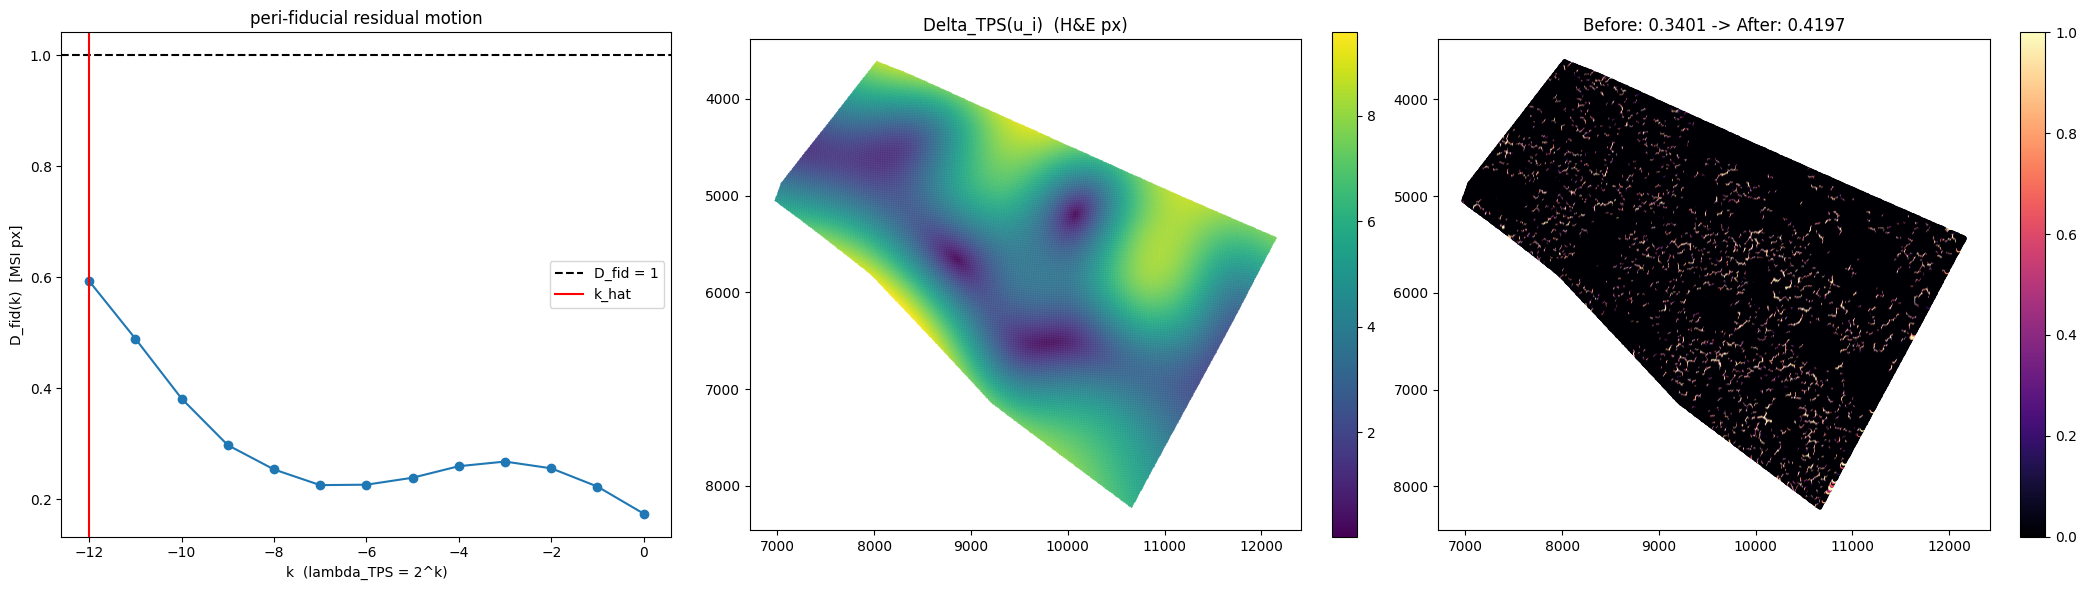

In [36]:
mag = np.linalg.norm(delta_tps, axis=1)

fig, ax = plt.subplots(1, 3, figsize=(21, 6))

ks = sorted(dfid_hist)
ax[0].plot(ks, [dfid_hist[k] for k in ks], "o-")
ax[0].axhline(1.0, color="k", ls="--", label="D_fid = 1")
ax[0].axvline(k_hat, color="red", label="k_hat")
ax[0].set_xlabel("k  (lambda_TPS = 2^k)"); ax[0].set_ylabel("D_fid(k)  [MSI px]")
ax[0].set_title("peri-fiducial residual motion"); ax[0].legend()

qv = ax[1].quiver(T0[:, 0], T0[:, 1], delta_tps[:, 0], delta_tps[:, 1],
                  mag, angles="xy", scale_units="xy", scale=1, cmap="viridis", width=0.002)
ax[1].set_title("Delta_TPS(u_i)  (H&E px)"); ax[1].set_aspect("equal"); ax[1].invert_yaxis()
fig.colorbar(qv, ax=ax[1], fraction=0.046)

sc = ax[2].scatter(T1[:, 0], T1[:, 1], c=s_T1, s=4, cmap="magma")
ax[2].set_title(f"Before: {corr0:.4f} -> After: {corr1:.4f}")
ax[2].set_aspect("equal"); ax[2].invert_yaxis()
fig.colorbar(sc, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.show()


## Chunk 15 — napari alignment comparison (optional QC)

Overlays, on the full H&E image, the same signal at the **initial** ($T_0$) and
**TPS-refined** ($T_1$) spot positions so the effect of the fine alignment can be inspected
layer-by-layer in napari:

- `s @ T0` vs `s @ T1` — the sinusoid soft field $f$ sampled at each geometry (same
  colormap; if the TPS helped, the $T_1$ layer should sit more tightly on the bright
  sinusoidal network of the H&E).
- `q0 @ T0` vs `q0 @ T1` — the frozen molecular metafeature at each geometry.
- one example ion map (`get_mz_column`) at $T_1$.
- TPS displacement magnitude at $T_0$.

Toggle layers and use the *Point Sizes* dock widget. Helpers are ported verbatim from
`feature_based_alignment_nuclei.ipynb`. Requires a display — `napari.run()` opens a blocking
interactive window and will not work headless.


In [41]:
import napari
from qtpy.QtWidgets import QWidget, QVBoxLayout, QHBoxLayout, QLabel, QSlider
from qtpy.QtCore import Qt


def _add_point_size_widget(viewer, points_layers, size_range=(1, 50)):
    """Dock widget with one point-size slider per points layer.

    Args:
        viewer (napari.Viewer): the target viewer.
        points_layers (list[napari.layers.Points]): layers to expose a slider for.
        size_range (tuple[int, int]): (min, max) selectable point size.

    Returns:
        QWidget: the docked panel (also added to the viewer).
    """
    panel = QWidget()
    layout = QVBoxLayout()
    panel.setLayout(layout)

    for pts_layer in points_layers:
        row = QHBoxLayout()
        label = QLabel(pts_layer.name)
        slider = QSlider(Qt.Horizontal)
        slider.setMinimum(size_range[0])
        slider.setMaximum(size_range[1])
        current = int(np.atleast_1d(pts_layer.size).ravel()[0]) if len(pts_layer.data) else size_range[0]
        slider.setValue(current)

        def make_callback(layer):
            def callback(value):
                layer.size = np.full(len(layer.data), value)
                layer.refresh()
            return callback

        slider.valueChanged.connect(make_callback(pts_layer))
        row.addWidget(label)
        row.addWidget(slider)
        layout.addLayout(row)

    viewer.window.add_dock_widget(panel, area="right", name="Point Sizes")
    return panel


def view_signals_on_he_napari(he_img, layers, point_size=6):
    """Open a napari viewer: H&E image + one coloured points layer per signal.

    Args:
        he_img (np.ndarray): (H, W, 3) RGB H&E image.
        layers (list[dict]): each dict has keys "name" (str), "coords_he" ((N, 2) (x, y)
            H&E-pixel coords), "values" ((N,) continuous values), optional "colormap"
            (napari colormap name, default "viridis"), and optional "clip" ((lo_pct,
            hi_pct) percentiles to clip the shown values to for colour contrast). Only
            points with value > 0 are shown.
        point_size (int): initial point size for every layer.

    Returns:
        napari.Viewer: the running viewer.
    """
    viewer = napari.Viewer()
    viewer.add_image(he_img, name="H&E", rgb=True)

    points_layers = []
    for layer in layers:
        coords_he = layer["coords_he"]
        values = np.asarray(layer["values"], dtype=float)
        colormap = layer.get("colormap", "viridis")

        mask = values > 0
        shown = values[mask]
        clip = layer.get("clip")                            # e.g. (1, 99) percentiles
        if clip is not None and shown.size:
            lo, hi = np.percentile(shown, clip)
            shown = np.clip(shown, lo, hi)

        points_yx = coords_he[:, ::-1]                      # napari uses (row, col) = (y, x)
        pts_layer = viewer.add_points(
            points_yx[mask], name=layer["name"], features={"value": shown},
            face_color="value", face_colormap=colormap, size=point_size, border_width=0,
        )
        points_layers.append(pts_layer)

    _add_point_size_widget(viewer, points_layers)
    napari.run()
    return viewer


def get_mz_column(spot_feature_matrix, mz_labels, mz_value, mz_tol=0.0042):
    """Intensity column for the m/z bin nearest a requested value.

    Args:
        spot_feature_matrix (scipy.sparse matrix | np.ndarray): (n, n_features) intensities.
        mz_labels (np.ndarray): (n_features,) m/z label per column.
        mz_value (float): requested m/z.
        mz_tol (float): warn if the nearest bin is farther than this from mz_value.

    Returns:
        values (np.ndarray): (n,) intensities for the matched column.
        matched_mz (float): the m/z of the matched bin.
    """
    idx = int(np.argmin(np.abs(mz_labels - mz_value)))
    matched_mz = float(mz_labels[idx])
    if abs(matched_mz - mz_value) > mz_tol:
        print(f"Warning: nearest bin {matched_mz:.4f} is {abs(matched_mz - mz_value):.4f} from {mz_value}")
    values = np.asarray(spot_feature_matrix[:, idx].todense()).ravel() \
        if sp.issparse(spot_feature_matrix) else np.asarray(spot_feature_matrix[:, idx]).ravel()
    return values, matched_mz


In [43]:
# sinusoid soft field at each geometry
s_at_T0 = project_field(f_interp, T0)
s_at_T1 = project_field(f_interp, T1)
disp_mag = np.linalg.norm(delta_tps, axis=1)

# one example ion map; change mz_value to any m/z present in mz_labels
mz_values, matched_mz = get_mz_column(spot_feature_matrix, mz_labels, mz_value=190.8660)

viewer = view_signals_on_he_napari(
    he_img,
    layers=[
        {"name": "s @ T0 (sinusoid field)", "coords_he": T0, "values": s_at_T0, "colormap": "viridis", "clip": (1, 99)},
        {"name": "s @ T1 (sinusoid field)", "coords_he": T1, "values": s_at_T1, "colormap": "viridis", "clip": (1, 99)},
        {"name": "q0 @ T0 (metafeature)",   "coords_he": T0, "values": q0 - q0.min(), "colormap": "magma", "clip": (1, 99)},
        {"name": "q0 @ T1 (metafeature)",   "coords_he": T1, "values": q0 - q0.min(), "colormap": "magma", "clip": (1, 99)},
        {"name": f"mz {matched_mz:.4f} @ T1", "coords_he": T1, "values": mz_values, "colormap": "plasma", "clip": (1, 99)},
        {"name": "|Delta_TPS| @ T0",         "coords_he": T0, "values": disp_mag, "colormap": "cividis", "clip": (1, 99)},
    ],
    point_size=6,
)
